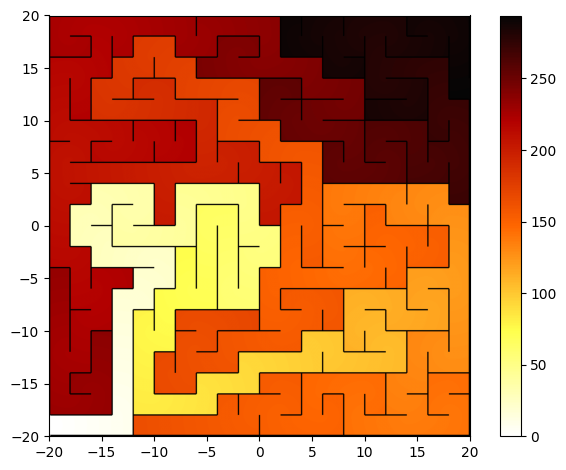

/tmp/ipykernel_618/3650023111.py:407: RuntimeWarning: overflow encountered in square
  grad_norm = np.sqrt(Tx**2 + Ty**2)


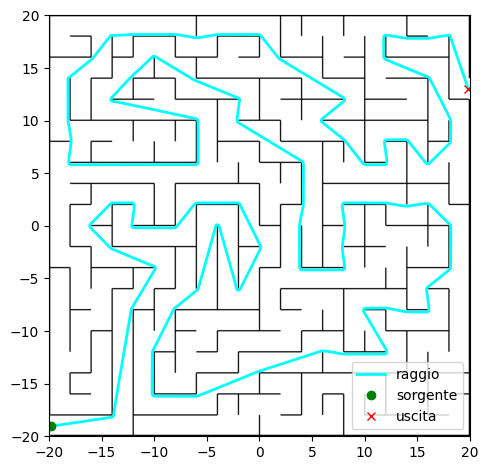

/tmp/ipykernel_618/3650023111.py:532: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_dom = plt.cm.get_cmap('gray').copy()   # <-- 'gray' non 'Greys': qui alto=bianco


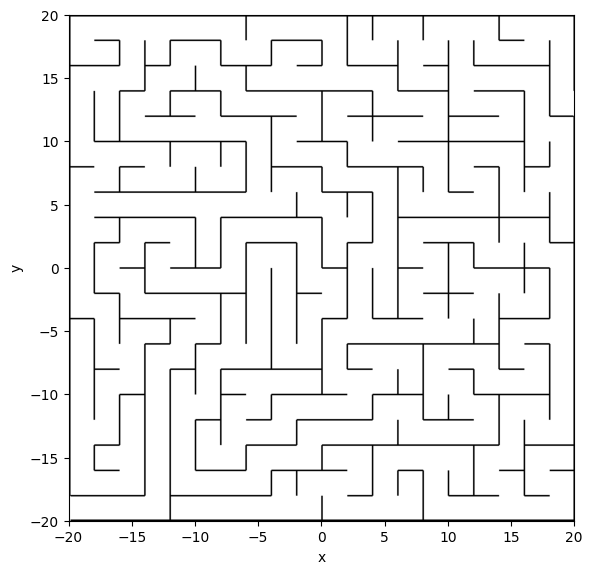

In [ ]:
# ==============================================================================
# ------------------GOLD-STANDARD SU LABIRINTO COMPLESSO------------------------
# ==============================================================================

#------------------  LIBRERIE --------------------------------------------------

import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
import numpy.ma as ma
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive
from scipy.ndimage import distance_transform_edt

#------------------  DISCRETIZZAZIONE DEL DOMINIO ------------------------------

# dominio 2000x2000

nx = 2000
ny = 2000
nRows = 2000
nCols = 2000
sidex = 20
sidey = 20
domain = [-sidex, sidex, -sidey, sidey]
x = np.linspace(domain[0], domain[1], nx)
y = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[X, Y] = np.meshgrid(x, y)
eps = 1e-6

#------------------  GENERATORE DI LABIRINTO (RECURSIVE BACKTRACKER) -----------

def generate_maze(rows, cols, seed=None):
    """
    Genera un labirinto 'perfetto' (un solo percorso tra due celle qualsiasi)
    con l'algoritmo recursive backtracker (DFS randomizzata).

    Restituisce due maschere booleane di muri interni:
      horiz_wall[r, c]  = True  -> muro tra cella (r,c) e (r+1,c)   [shape (rows-1, cols)]
      vert_wall[r, c]   = True  -> muro tra cella (r,c) e (r,c+1)   [shape (rows,  cols-1)]
    """
    rng = np.random.default_rng(seed)

    visited = np.zeros((rows, cols), dtype=bool)
    horiz_wall = np.ones((rows - 1, cols), dtype=bool)
    vert_wall  = np.ones((rows, cols - 1), dtype=bool)

    stack = [(0, 0)]
    visited[0, 0] = True

    while stack:
        r, c = stack[-1]

        neighbors = []
        if r > 0 and not visited[r - 1, c]:
            neighbors.append(('N', r - 1, c))
        if r < rows - 1 and not visited[r + 1, c]:
            neighbors.append(('S', r + 1, c))
        if c > 0 and not visited[r, c - 1]:
            neighbors.append(('W', r, c - 1))
        if c < cols - 1 and not visited[r, c + 1]:
            neighbors.append(('E', r, c + 1))

        if neighbors:
            direction, nr, nc = neighbors[rng.integers(len(neighbors))]

            if direction == 'N':
                horiz_wall[r - 1, c] = False
            elif direction == 'S':
                horiz_wall[r, c] = False
            elif direction == 'W':
                vert_wall[r, c - 1] = False
            elif direction == 'E':
                vert_wall[r, c] = False

            visited[nr, nc] = True
            stack.append((nr, nc))
        else:
            stack.pop()

    return horiz_wall, vert_wall


def build_F_from_maze(nx, ny, rows, cols, horiz_wall, vert_wall,
                       wall_thickness=6, entrance_row=None, exit_row=None):
    """
    Rasterizza il labirinto (celle rows x cols) sulla griglia fine nx x ny,
    aprendo un varco sul bordo sinistro (ingresso) e uno sul bordo destro (uscita).

    Restituisce F, e gli indici (iy) del centro dell'ingresso e dell'uscita
    in coordinate della griglia fine.
    """
    F = np.ones((ny, nx), dtype=np.float32)

    cell_h = ny // rows
    cell_w = nx // cols
    t2 = max(wall_thickness // 2, 1)

    # bordo esterno del labirinto
    F[0:wall_thickness, :]   = np.inf   # bordo sopra
    F[-wall_thickness:, :]   = np.inf   # bordo sotto
    F[:, 0:wall_thickness]   = np.inf   # bordo sinistro
    F[:, -wall_thickness:]   = np.inf   # bordo destro

    # muri orizzontali interni (tra riga r e r+1 di celle)
    for r in range(rows - 1):
        y_pos = (r + 1) * cell_h
        for c in range(cols):
            if horiz_wall[r, c]:
                x0 = c * cell_w
                x1 = (c + 1) * cell_w
                F[y_pos - t2:y_pos + t2, x0:x1] = np.inf

    # muri verticali interni (tra colonna c e c+1 di celle)
    for r in range(rows):
        y0 = r * cell_h
        y1 = (r + 1) * cell_h
        for c in range(cols - 1):
            if vert_wall[r, c]:
                x_pos = (c + 1) * cell_w
                F[y0:y1, x_pos - t2:x_pos + t2] = np.inf

    # default: ingresso a sinistra vicino all'alto, uscita a destra vicino al basso
    # (stessa impostazione "diagonale" dell'immagine di riferimento)
    if entrance_row is None:
        entrance_row = 0
    if exit_row is None:
        exit_row = rows - 1

    ey0, ey1 = entrance_row * cell_h, (entrance_row + 1) * cell_h
    xy0, xy1 = exit_row * cell_h, (exit_row + 1) * cell_h

    F[ey0:ey1, 0:wall_thickness]    = 1.0   # varco d'ingresso sul bordo sinistro
    F[xy0:xy1, nx - wall_thickness:] = 1.0  # varco d'uscita sul bordo destro

    iy_entrance = (ey0 + ey1) // 2
    iy_exit     = (xy0 + xy1) // 2

    return F, iy_entrance, iy_exit


#------------------  CAMPO DI VELOCITA' (LABIRINTO COMPLESSO) ------------------

h = dx

MAZE_ROWS = 20      # numero di celle del labirinto in verticale
MAZE_COLS = 20      # numero di celle del labirinto in orizzontale
WALL_THICKNESS = 6  # spessore dei muri in pixel della griglia fine
MAZE_SEED = 0       # fissare il seed per riproducibilità (None per casuale)

# riga di cella (0-indexed) in cui aprire ingresso/uscita: qui ingresso in alto
# a sinistra e uscita in basso a destra, come nell'immagine di riferimento
ENTRANCE_CELL_ROW = 0
EXIT_CELL_ROW = MAZE_ROWS - 4

horiz_wall, vert_wall = generate_maze(MAZE_ROWS, MAZE_COLS, seed=MAZE_SEED)

F, iy_entrance, iy_exit = build_F_from_maze(
    nx, ny, MAZE_ROWS, MAZE_COLS, horiz_wall, vert_wall,
    wall_thickness=WALL_THICKNESS,
    entrance_row=ENTRANCE_CELL_ROW,
    exit_row=EXIT_CELL_ROW
)

wall_mask = np.isinf(F)

#------------------  FASCIA DI SICUREZZA AI MURI -------------------------------

def inflate_walls_smooth(F, wall_mask, margin_cells, penalty_factor):
    F_smooth = F.copy()
    dist_to_wall = distance_transform_edt(~wall_mask)   # distanza in celle dal muro più vicino
    ramp = np.clip(dist_to_wall / margin_cells, 0.0, 1.0)
    F_ramped = penalty_factor + (1.0 - penalty_factor) * ramp
    F_smooth[~wall_mask] = F_ramped[~wall_mask]
    return F_smooth

F_safe = inflate_walls_smooth(F, wall_mask, margin_cells=6, penalty_factor=0.3)

# ==============================================================================
# CALCOLO ICONALE PARALLELIZZATO IN RAWKERNEL
# ==============================================================================

#------------------  SORGENTE (posizionata esattamente al varco d'ingresso) ---

# ix0/iy0 = indici di riga/colonna della sorgente: la mettiamo appena dentro
# il varco d'ingresso sul bordo sinistro, così il fronte parte "dall'ingresso
# del labirinto" invece che da un angolo del dominio
ix0 = WALL_THICKNESS + 2
iy0 = iy_entrance

T = np.full(X.shape, 1e30, dtype=np.float32)
T[iy0, ix0] = 0.0

#------------------  UPLOAD CPU -> GPU -----------------------------------------

T_gpu = cp.array(T)
F_gpu = cp.array(F_safe)

#------------------ GODUNOV 1 --------------------------------------------------

godunov_code = godunov_code = r'''
extern "C" __global__
void godunov_update_full(
    const float* T,
    const float* F,
    float*       T_new,
    int          nRows,
    int          nCols,
    float        h
) {

    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= nRows * nCols) return;

    int r = idx / nCols;
    int c = idx % nCols;

    // nodo muro
    float f = F[idx];
    if (isinf(f)) {
        T_new[idx] = 1e30f;
        return;
    }

    // nodo sorgente: non toccare mai
    if (T[idx] == 0.0f) {
        T_new[idx] = 0.0f;
        return;
    }

    float left, right, down, up;

    if (c - 1 < 0 || isinf(F[r * nCols + (c-1)]))
        left = 1e30f;
    else
        left = T[r * nCols + (c-1)];

    if (c + 1 >= nCols || isinf(F[r * nCols + (c+1)]))
        right = 1e30f;
    else
        right = T[r * nCols + (c+1)];

    if (r - 1 < 0 || isinf(F[(r-1) * nCols + c]))
        down = 1e30f;
    else
        down = T[(r-1) * nCols + c];

    if (r + 1 >= nRows || isinf(F[(r+1) * nCols + c]))
        up = 1e30f;
    else
        up = T[(r+1) * nCols + c];

    float Txmin = fminf(left, right);
    float Tymin = fminf(down, up);

    float a = fminf(Txmin, Tymin);
    float b = fmaxf(Txmin, Tymin);

    float rhs = h / f;

    float result;
    if ((b - a) < rhs) {
        float disc = 2.0f * rhs*rhs - (a - b)*(a - b);
        if (disc < 0.0f) disc = 0.0f;
        result = (a + b + sqrtf(disc)) / 2.0f;
    } else {
        result = a + rhs;
    }

    T_new[idx] = result;
}
'''

godunov_ker = cp.RawKernel(godunov_code, 'godunov_update_full')


#------------------  AGGIORNAMENTO FIM JACOBI ----------------------------------

#  versione ottimizzata: controlla ogni 25 passi anzichè ad ogni passo, per
#  allegerire il carico computazionale

def FIM_senzaLista_raw(T, F, check_every=25):
    threads_per_block = 256
    n = nRows * nCols
    blocchi = (n + threads_per_block - 1) // threads_per_block

    # due buffer fissi: eliminano la copy() e l'allocazione ripetuta ad ogni iterazione
    T_a = T.ravel().copy()
    T_b = cp.empty(n, dtype=cp.float32)
    T_new = cp.empty(n, dtype=cp.float32)
    F_flat = F.ravel()

    cur, nxt = T_a, T_b
    it = 0

    while True:
        godunov_ker(
            (blocchi,), (threads_per_block,),
            (cur, F_flat, T_new,
             cp.int32(nRows), cp.int32(nCols), cp.float32(h))
        )

        cp.minimum(cur, T_new, out=nxt)  # scrive direttamente nel buffer esistente

        # il controllo di convergenza (che forza sync GPU->CPU) viene fatto
        # solo ogni check_every iterazioni, non ad ogni passo
        if it % check_every == 0:
            maxdiff = float(cp.max(cp.abs(cur - nxt)))
            if maxdiff < eps:
                cur = nxt
                break

        cur, nxt = nxt, cur
        it += 1

    return cur.reshape(nRows, nCols)

#------------------  SOLVE AND UPLOAD GPU -> CPU -------------------------------

T_final_gpu = FIM_senzaLista_raw(T_gpu, F_gpu)

# ── torna su CPU per il plot ──────────────────────────────────────────────────
T_final = cp.asnumpy(T_final_gpu)

#------------------  STAMPA DEI RISULTATI --------------------------------------

# maschera i muri (e qualunque cella rimasta a sentinella) prima del plot
T_masked = ma.masked_where(T_final >= 1e29, T_final)

fig, ax = plt.subplots()
im = ax.imshow(T_masked, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')
plt.colorbar(im, ax=ax)

stops = np.array([
    [1.00, 1.00, 1.00],
    [1.00, 1.00, 0.30],
    [1.00, 0.40, 0.00],
    [0.70, 0.00, 0.00],
    [0.02, 0.02, 0.02],
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)
cmap2.set_bad(color='black')   # colore per le celle mascherate (i muri)
im.set_cmap(cmap2)
plt.tight_layout()
plt.show()


# ==============================================================================
# CALCOLO DEI RAGGI
# ==============================================================================

#------------------ DISCRETIZZAZIONE DEL GRADIENTE -----------------------------

def Gradient_FD(T_final, F, dx, dy):
    wall_mask = np.isinf(F)
    nRows, nCols = T_final.shape

    Tx = np.zeros_like(T_final)
    Ty = np.zeros_like(T_final)

    # --- Derivata rispetto a x (colonne) ---
    valid = ~wall_mask

    left_ok  = np.zeros_like(valid)
    right_ok = np.zeros_like(valid)
    left_ok[:, 1:]  = valid[:, :-1]   # vicino a sinistra è valido
    right_ok[:, :-1] = valid[:, 1:]   # vicino a destra è valido

    T_left  = np.full_like(T_final, np.nan)
    T_right = np.full_like(T_final, np.nan)
    T_left[:, 1:]  = T_final[:, :-1]
    T_right[:, :-1] = T_final[:, 1:]

    both_x = left_ok & right_ok
    only_left_x  = left_ok & ~right_ok    # solo sinistra disponibile → backward diff
    only_right_x = right_ok & ~left_ok    # solo destra disponibile → forward diff

    Tx[both_x] = (T_right[both_x] - T_left[both_x]) / (2 * dx)
    Tx[only_right_x] = (T_right[only_right_x] - T_final[only_right_x]) / dx
    Tx[only_left_x]  = (T_final[only_left_x] - T_left[only_left_x]) / dx
    # entrambi i vicini muro (o cella stessa muro) → Tx resta 0

    # --- Derivata rispetto a y (righe) ---
    down_ok = np.zeros_like(valid)
    up_ok   = np.zeros_like(valid)
    down_ok[1:, :] = valid[:-1, :]    # vicino sotto è valido
    up_ok[:-1, :]  = valid[1:, :]     # vicino sopra è valido

    T_down = np.full_like(T_final, np.nan)
    T_up   = np.full_like(T_final, np.nan)
    T_down[1:, :] = T_final[:-1, :]
    T_up[:-1, :]  = T_final[1:, :]

    both_y = down_ok & up_ok
    only_down_y = down_ok & ~up_ok
    only_up_y   = up_ok & ~down_ok

    Ty[both_y] = (T_up[both_y] - T_down[both_y]) / (2 * dy)
    Ty[only_up_y]   = (T_up[only_up_y] - T_final[only_up_y]) / dy
    Ty[only_down_y] = (T_final[only_down_y] - T_down[only_down_y]) / dy

    # --- Rinormalizzazione secondo l'eikonale: |grad T| = 1/F ---
    grad_norm = np.sqrt(Tx**2 + Ty**2)
    scale = np.zeros_like(grad_norm)
    finite_F = np.isfinite(F) & (grad_norm > 1e-12)
    scale[finite_F] = 1.0 / (F[finite_F] * grad_norm[finite_F])

    Tx = np.where(finite_F, Tx * scale, 0.0)
    Ty = np.where(finite_F, Ty * scale, 0.0)

    # azzera esplicitamente le celle muro
    Tx[wall_mask] = 0.0
    Ty[wall_mask] = 0.0

    return Tx, Ty

Tx = np.zeros_like(T_final)
Ty = np.zeros_like(T_final)

Tx, Ty = Gradient_FD(T_final, F, dx, dy)

#------------------  ADATTAMENTO DEI MURI --------------------------------------

def fill_wall_nans(field, wall_mask):
    """Sostituisce i valori nelle celle muro con quelli della cella valida più vicina."""
    # indici della cella valida più vicina per ogni punto della griglia
    idx = distance_transform_edt(wall_mask, return_distances=False, return_indices=True)
    return field[tuple(idx)]

#------------------  INTERPOLAZIONE BILINEARE ----------------------------------

wall_mask = np.isinf(F)

Tx_filled = fill_wall_nans(Tx, wall_mask)
Ty_filled = fill_wall_nans(Ty, wall_mask)

Tx_interp = RegularGridInterpolator((y, x), Tx_filled, method='linear',
                                     bounds_error=False, fill_value=None)
Ty_interp = RegularGridInterpolator((y, x), Ty_filled, method='linear',
                                     bounds_error=False, fill_value=None)


def grad_at(pt, Tx_interp, Ty_interp):
    """pt = (px, py) in coordinate cartesiane."""
    px, py = pt
    point = np.array([[py, px]])  # RegularGridInterpolator vuole shape (n_points, n_dims)
    gx = Tx_interp(point)[0]
    gy = Ty_interp(point)[0]
    if not (np.isfinite(gx) and np.isfinite(gy)):
        return np.array([0.0, 0.0])
    return np.array([gx, gy])

#------------------  INTEGRAZIONE RK4 ------------------------------------------

def trace_ray_rk4(start_pt, Tx_interp, Ty_interp, source_pt, ds, max_steps):
    """
    Integra all'indietro seguendo -grad(T) a partire da start_pt (uscita)
    fino ad avvicinarsi a source_pt (sorgente).
    """
    pt = np.array(start_pt, dtype=float)
    ray = [pt.copy()]

    for step in range(max_steps):

        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
          break

        k1 = -grad_at(pt, Tx_interp, Ty_interp)
        if np.linalg.norm(k1) < 1e-12:
            break
        k2 = -grad_at(pt + 0.5*ds*k1, Tx_interp, Ty_interp)
        k3 = -grad_at(pt + 0.5*ds*k2, Tx_interp, Ty_interp)
        k4 = -grad_at(pt + ds*k3, Tx_interp, Ty_interp)

        dpt = (k1 + 2*k2 + 2*k3 + k4) / 6.0
        pt_new = pt + ds * dpt

        ray.append(pt_new.copy())

        # criterio di arresto: raggio arrivato vicino alla sorgente
        if np.linalg.norm(pt_new - np.array(source_pt)) < ds:
            ray.append(np.array(source_pt, dtype=float))
            break

        # criterio di stagnazione (raggio bloccato, es. contro un muro)
        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
            break

        pt = pt_new

    return np.array(ray)

#------------------  CALCOLO DEL RAGGIO ALL'INDIETRO ---------------------------

# coordinate cartesiane del punto sorgente (ingresso del labirinto)
source_pt = (x[ix0], y[iy0])

# punto d'uscita: coincide con il varco d'uscita sul bordo destro
ix_exit = nx - WALL_THICKNESS - 2
exit_pt = (x[ix_exit], y[iy_exit])

ds = dx  # passo di integrazione
max_steps = 20000

ray = trace_ray_rk4(exit_pt, Tx_interp, Ty_interp, source_pt, ds, max_steps)


#------------------  STAMPA DEI RISULTATI --------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal', cmap=cmap2)
# plt.colorbar(im, ax=ax)

ax.plot(ray[:, 0], ray[:, 1], color='cyan', linewidth=2, label='raggio')
ax.plot(*source_pt, 'go', label='sorgente')
ax.plot(*exit_pt, 'rx', label='uscita')
ax.legend()
plt.tight_layout()
plt.show()

#------------------  PLOT DEL DOMINIO (SOLO F, LABIRINTO) ----------------------

F_plot = np.where(np.isinf(F), np.nan, F)

fig, ax = plt.subplots(figsize=(6,6))

cmap_dom = plt.cm.get_cmap('gray').copy()   # <-- 'gray' non 'Greys': qui alto=bianco
cmap_dom.set_bad(color='black')             # i muri (NaN) restano neri

im = ax.imshow(F_plot, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal', cmap=cmap_dom, vmin=0, vmax=1)


ax.set_xlabel("x")
ax.set_ylabel("y")

plt.tight_layout()
plt.show()

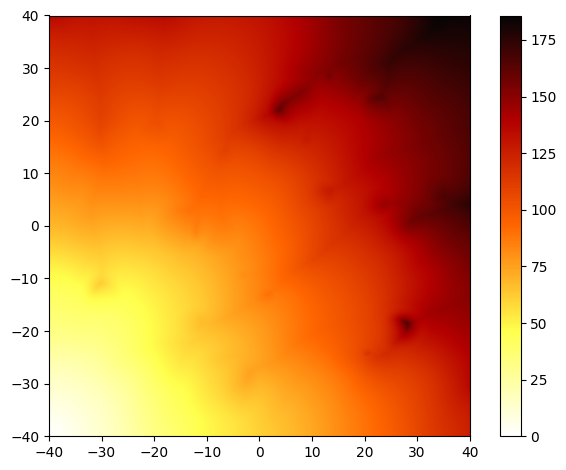

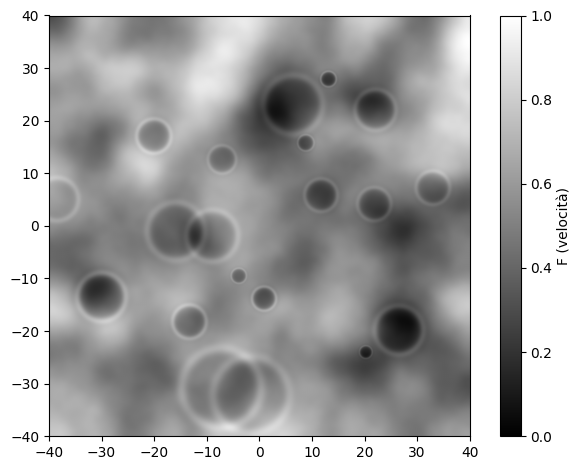

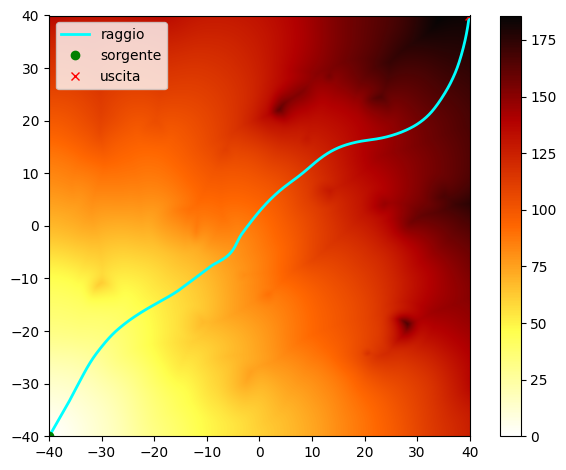

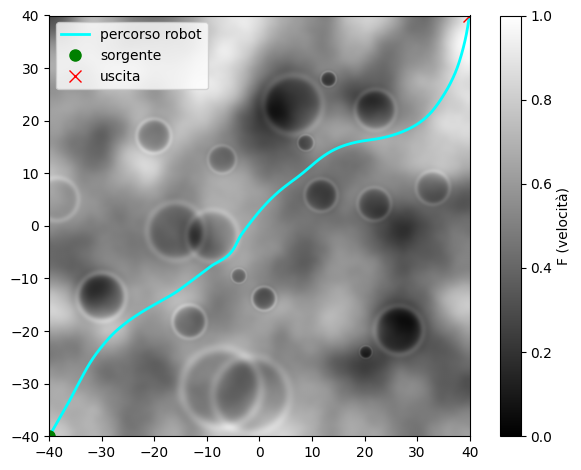

In [ ]:
# ==============================================================================
# VERSIONE FIM JACOBI SENZA LISTA PARALLELIZZATA IN RAWKERNEL SU SUPERFICIE LUNARE
# ==============================================================================

#------------------  LIBRERIE --------------------------------------------------

import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
import numpy.ma as ma
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive
from scipy.ndimage import distance_transform_edt, gaussian_filter

#------------------  DISCRETIZZAZIONE DEL DOMINIO ------------------------------

# dominio 5000x5000

nx = 4000
ny = 4000
nRows = 4000
nCols = 4000
sidex = 40
sidey = 40
domain = [-sidex, sidex, -sidey, sidey]
x = np.linspace(domain[0], domain[1], nx)
y = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[X, Y] = np.meshgrid(x, y)
eps = 1e-6

ix0 = 5
iy0 = 5


#------------------  CAMPO DI VELOCITA' (SUPERFICIE LUNARE ETEROGENEA) ---------

h = dx

def generate_lunar_terrain(nx, ny, seed=0,
                            n_craters=20,
                            crater_r_range=(30.0, 250.0),
                            crater_depth_range=(1.2, 2.0),
                            f_min=0.05, f_max=1.0):
    """
    Genera un campo di velocità F eterogeneo in stile "superficie lunare":

      1) un fondo di rumore frattale liscio (somma di rumori gaussiani
         filtrati a scale via via più piccole) che simula le ondulazioni
         naturali del terreno (tipo mari/altopiani lunari);
      2) un certo numero di crateri da impatto, ciascuno con una conca
         centrale (velocità ridotta: più difficile attraversarla) e un
         bordo/rim rialzato (velocità leggermente maggiore, come il
         materiale espulso e compattato sul bordo del cratere).

    Il risultato viene rinormalizzato in [f_min, f_max] (f_min > 0 per
    evitare F = 0, che nell'aggiornamento di Godunov produrrebbe rhs = h/F
    infinito).
    """
    rng = np.random.default_rng(seed)

    #  ---- 1) fondo di rumore frattale (più scale, ampiezza decrescente) ----
    terrain = np.zeros((ny, nx), dtype=np.float32)
    scales = [200, 100, 50, 25]      # sigma del filtro gaussiano, in pixel
    amplitude = 1.0
    for s in scales:
        noise = rng.standard_normal((ny, nx)).astype(np.float32)
        smooth = gaussian_filter(noise, sigma=s)
        smooth /= (smooth.std() + 1e-8)
        terrain += amplitude * smooth
        amplitude *= 0.25

    #  ---- 2) crateri: conca centrale + rim rialzato, aggiunti localmente ----
    for _ in range(n_craters):
        cx = int(np.clip(rng.normal(nx / 2, nx / 4), 0, nx - 1))
        cy = int(np.clip(rng.normal(ny / 2, ny / 4), 0, ny - 1))
        R = rng.uniform(*crater_r_range)
        depth = rng.uniform(*crater_depth_range)

        pad = int(R * 3)
        x0, x1 = max(cx - pad, 0), min(cx + pad, nx)
        y0, y1 = max(cy - pad, 0), min(cy + pad, ny)

        yy_local, xx_local = np.mgrid[y0:y1, x0:x1]
        dist = np.sqrt((xx_local - cx) ** 2 + (yy_local - cy) ** 2)
        norm_r = dist / R

        bowl = -depth * np.exp(-(norm_r ** 4))          # era **2: ora pareti più ripide
        rim  = 0.5 * depth * np.exp(-((norm_r - 1.0) ** 2) / 0.02)  # rim più stretto e marcato (era /0.05)

        terrain[y0:y1, x0:x1] += (bowl + rim).astype(np.float32)

    #  ---- normalizzazione finale in (f_min, f_max] ----
    terrain *= 0.25
    terrain -= terrain.min()
    terrain /= (terrain.max() + 1e-8)          # ora in [0, 1]
    F = f_min + (f_max - f_min) * terrain      # ora in [f_min, f_max]

    return F.astype(np.float32)


F = generate_lunar_terrain(
    nx, ny,
    seed=0,
    n_craters=20,
    crater_r_range=(50.0, 400.0),      # erano (30, 250)
    crater_depth_range=(1.2, 2.0),     # erano (0.3, 0.9): ora sforano il fondo attenuato
    f_min=0.05, f_max=1.0
)

wall_mask = np.isinf(F)   # nessun vero "muro": qui è ovunque False (F è sempre finito)

#------------------  FASCIA DI SICUREZZA AI MURI -------------------------------
# (non ci sono muri in questo scenario, ma la funzione resta per coerenza con
#  gli altri script: qui è sostanzialmente un no-op perché wall_mask è vuota)

def inflate_walls_smooth(F, wall_mask, margin_cells, penalty_factor):
    F_smooth = F.copy()
    dist_to_wall = distance_transform_edt(~wall_mask)   # distanza in celle dal muro più vicino
    ramp = np.clip(dist_to_wall / margin_cells, 0.0, 1.0)
    F_ramped = penalty_factor + (1.0 - penalty_factor) * ramp
    F_smooth[~wall_mask] = F_ramped[~wall_mask]
    return F_smooth

F_safe = inflate_walls_smooth(F, wall_mask, margin_cells=6, penalty_factor=0.3)

# ==============================================================================
# CALCOLO ICONALE PARALLELIZZATO IN RAWKERNEL
# ==============================================================================

#------------------  SORGENTE --------------------------------------------------

T = np.full(X.shape, 1e30, dtype=np.float32)
T[iy0, ix0] = 0.0

#------------------  UPLOAD CPU -> GPU -----------------------------------------

T_gpu = cp.array(T)
F_gpu = cp.array(F)

#------------------ GODUNOV 1 --------------------------------------------------

godunov_code = godunov_code = r'''
extern "C" __global__
void godunov_update_full(
    const float* T,
    const float* F,
    float*       T_new,
    int          nRows,
    int          nCols,
    float        h
) {

    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= nRows * nCols) return;

    int r = idx / nCols;
    int c = idx % nCols;

    // nodo muro
    float f = F[idx];
    if (isinf(f)) {
        T_new[idx] = 1e30f;
        return;
    }

    // nodo sorgente: non toccare mai
    if (T[idx] == 0.0f) {
        T_new[idx] = 0.0f;
        return;
    }

    float left, right, down, up;

    if (c - 1 < 0 || isinf(F[r * nCols + (c-1)]))
        left = 1e30f;
    else
        left = T[r * nCols + (c-1)];

    if (c + 1 >= nCols || isinf(F[r * nCols + (c+1)]))
        right = 1e30f;
    else
        right = T[r * nCols + (c+1)];

    if (r - 1 < 0 || isinf(F[(r-1) * nCols + c]))
        down = 1e30f;
    else
        down = T[(r-1) * nCols + c];

    if (r + 1 >= nRows || isinf(F[(r+1) * nCols + c]))
        up = 1e30f;
    else
        up = T[(r+1) * nCols + c];

    float Txmin = fminf(left, right);
    float Tymin = fminf(down, up);

    float a = fminf(Txmin, Tymin);
    float b = fmaxf(Txmin, Tymin);

    float rhs = h / f;

    float result;
    if ((b - a) < rhs) {
        float disc = 2.0f * rhs*rhs - (a - b)*(a - b);
        if (disc < 0.0f) disc = 0.0f;
        result = (a + b + sqrtf(disc)) / 2.0f;
    } else {
        result = a + rhs;
    }

    T_new[idx] = result;
}
'''

godunov_ker = cp.RawKernel(godunov_code, 'godunov_update_full')


#------------------  AGGIORNAMENTO FIM JACOBI ----------------------------------

#  versione ottimizzata: controlla ogni 25 passi anzichè ad ogni passo, per
#  allegerire il carico computazionale

def FIM_senzaLista_raw(T, F, check_every=25):
    threads_per_block = 256
    n = nRows * nCols
    blocchi = (n + threads_per_block - 1) // threads_per_block

    # due buffer fissi: eliminano la copy() e l'allocazione ripetuta ad ogni iterazione
    T_a = T.ravel().copy()
    T_b = cp.empty(n, dtype=cp.float32)
    T_new = cp.empty(n, dtype=cp.float32)
    F_flat = F.ravel()

    cur, nxt = T_a, T_b
    it = 0

    while True:
        godunov_ker(
            (blocchi,), (threads_per_block,),
            (cur, F_flat, T_new,
             cp.int32(nRows), cp.int32(nCols), cp.float32(h))
        )

        cp.minimum(cur, T_new, out=nxt)  # scrive direttamente nel buffer esistente

        # il controllo di convergenza (che forza sync GPU->CPU) viene fatto
        # solo ogni check_every iterazioni, non ad ogni passo
        if it % check_every == 0:
            maxdiff = float(cp.max(cp.abs(cur - nxt)))
            if maxdiff < eps:
                cur = nxt
                break

        cur, nxt = nxt, cur
        it += 1

    return cur.reshape(nRows, nCols)

#------------------  SOLVE AND UPLOAD GPU -> CPU -------------------------------

T_final_gpu = FIM_senzaLista_raw(T_gpu, F_gpu)

# ── torna su CPU per il plot ──────────────────────────────────────────────────
T_final = cp.asnumpy(T_final_gpu)

#------------------  STAMPA DEI RISULTATI --------------------------------------

# maschera i muri (e qualunque cella rimasta a sentinella) prima del plot
T_masked = ma.masked_where(T_final >= 1e29, T_final)

fig, ax = plt.subplots()
im = ax.imshow(T_masked, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')
plt.colorbar(im, ax=ax)

stops = np.array([
    [1.00, 1.00, 1.00],
    [1.00, 1.00, 0.30],
    [1.00, 0.40, 0.00],
    [0.70, 0.00, 0.00],
    [0.02, 0.02, 0.02],
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)
cmap2.set_bad(color='black')   # colore per le celle mascherate (i muri)
im.set_cmap(cmap2)
plt.tight_layout()
plt.show()

# (opzionale) visualizzazione del campo F stesso, per controllare il terreno lunare
fig2, ax2 = plt.subplots()
im2 = ax2.imshow(F, extent=[x.min(), x.max(), y.min(), y.max()],
                  origin='lower', aspect='equal', cmap='gray', vmin=0.0, vmax=1.0)
plt.colorbar(im2, ax=ax2, label='F (velocità)')
plt.tight_layout()
plt.show()


# ==============================================================================
# CALCOLO DEI RAGGI
# ==============================================================================

#------------------ DISCRETIZZAZIONE DEL GRADIENTE -----------------------------

def Gradient_FD(T_final, F, dx, dy):
    wall_mask = np.isinf(F)
    nRows, nCols = T_final.shape

    Tx = np.zeros_like(T_final)
    Ty = np.zeros_like(T_final)

    # --- Derivata rispetto a x (colonne) ---
    valid = ~wall_mask

    left_ok  = np.zeros_like(valid)
    right_ok = np.zeros_like(valid)
    left_ok[:, 1:]  = valid[:, :-1]   # vicino a sinistra è valido
    right_ok[:, :-1] = valid[:, 1:]   # vicino a destra è valido

    T_left  = np.full_like(T_final, np.nan)
    T_right = np.full_like(T_final, np.nan)
    T_left[:, 1:]  = T_final[:, :-1]
    T_right[:, :-1] = T_final[:, 1:]

    both_x = left_ok & right_ok
    only_left_x  = left_ok & ~right_ok    # solo sinistra disponibile → backward diff
    only_right_x = right_ok & ~left_ok    # solo destra disponibile → forward diff

    Tx[both_x] = (T_right[both_x] - T_left[both_x]) / (2 * dx)
    Tx[only_right_x] = (T_right[only_right_x] - T_final[only_right_x]) / dx
    Tx[only_left_x]  = (T_final[only_left_x] - T_left[only_left_x]) / dx
    # entrambi i vicini muro (o cella stessa muro) → Tx resta 0

    # --- Derivata rispetto a y (righe) ---
    down_ok = np.zeros_like(valid)
    up_ok   = np.zeros_like(valid)
    down_ok[1:, :] = valid[:-1, :]    # vicino sotto è valido
    up_ok[:-1, :]  = valid[1:, :]     # vicino sopra è valido

    T_down = np.full_like(T_final, np.nan)
    T_up   = np.full_like(T_final, np.nan)
    T_down[1:, :] = T_final[:-1, :]
    T_up[:-1, :]  = T_final[1:, :]

    both_y = down_ok & up_ok
    only_down_y = down_ok & ~up_ok
    only_up_y   = up_ok & ~down_ok

    Ty[both_y] = (T_up[both_y] - T_down[both_y]) / (2 * dy)
    Ty[only_up_y]   = (T_up[only_up_y] - T_final[only_up_y]) / dy
    Ty[only_down_y] = (T_final[only_down_y] - T_down[only_down_y]) / dy

    # --- Rinormalizzazione secondo l'eikonale: |grad T| = 1/F ---
    grad_norm = np.sqrt(Tx**2 + Ty**2)
    scale = np.zeros_like(grad_norm)
    finite_F = np.isfinite(F) & (grad_norm > 1e-12)
    scale[finite_F] = 1.0 / (F[finite_F] * grad_norm[finite_F])

    Tx = np.where(finite_F, Tx * scale, 0.0)
    Ty = np.where(finite_F, Ty * scale, 0.0)

    # azzera esplicitamente le celle muro
    Tx[wall_mask] = 0.0
    Ty[wall_mask] = 0.0

    return Tx, Ty

Tx = np.zeros_like(T_final)
Ty = np.zeros_like(T_final)

Tx, Ty = Gradient_FD(T_final, F, dx, dy)

#------------------  ADATTAMENTO DEI MURI --------------------------------------

def fill_wall_nans(field, wall_mask):
    """Sostituisce i valori nelle celle muro con quelli della cella valida più vicina."""
    # indici della cella valida più vicina per ogni punto della griglia
    idx = distance_transform_edt(wall_mask, return_distances=False, return_indices=True)
    return field[tuple(idx)]

#------------------  INTERPOLAZIONE BILINEARE ----------------------------------

wall_mask = np.isinf(F)

Tx_filled = fill_wall_nans(Tx, wall_mask)
Ty_filled = fill_wall_nans(Ty, wall_mask)

Tx_interp = RegularGridInterpolator((y, x), Tx_filled, method='linear',
                                     bounds_error=False, fill_value=None)
Ty_interp = RegularGridInterpolator((y, x), Ty_filled, method='linear',
                                     bounds_error=False, fill_value=None)


def grad_at(pt, Tx_interp, Ty_interp):
    """pt = (px, py) in coordinate cartesiane."""
    px, py = pt
    point = np.array([[py, px]])  # RegularGridInterpolator vuole shape (n_points, n_dims)
    gx = Tx_interp(point)[0]
    gy = Ty_interp(point)[0]
    if not (np.isfinite(gx) and np.isfinite(gy)):
        return np.array([0.0, 0.0])
    return np.array([gx, gy])

#------------------  INTEGRAZIONE RK4 ------------------------------------------

def trace_ray_rk4(start_pt, Tx_interp, Ty_interp, source_pt, ds, max_steps):
    """
    Integra all'indietro seguendo -grad(T) a partire da start_pt (uscita)
    fino ad avvicinarsi a source_pt (sorgente).
    """
    pt = np.array(start_pt, dtype=float)
    ray = [pt.copy()]

    for step in range(max_steps):

        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
          break

        k1 = -grad_at(pt, Tx_interp, Ty_interp)
        if np.linalg.norm(k1) < 1e-12:
            break
        k2 = -grad_at(pt + 0.5*ds*k1, Tx_interp, Ty_interp)
        k3 = -grad_at(pt + 0.5*ds*k2, Tx_interp, Ty_interp)
        k4 = -grad_at(pt + ds*k3, Tx_interp, Ty_interp)

        dpt = (k1 + 2*k2 + 2*k3 + k4) / 6.0
        pt_new = pt + ds * dpt

        ray.append(pt_new.copy())

        # criterio di arresto: raggio arrivato vicino alla sorgente
        if np.linalg.norm(pt_new - np.array(source_pt)) < ds:
            ray.append(np.array(source_pt, dtype=float))
            break

        # criterio di stagnazione (raggio bloccato, es. contro un muro)
        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
            break

        pt = pt_new

    return np.array(ray)

#------------------  CALCOLO DEL RAGGIO ALL'INDIETRO ---------------------------

# coordinate cartesiane del punto sorgente
source_pt = (x[ix0], y[iy0])

# punto d'uscita in alto a destra del dominio
exit_pt = (x[3995], y[3995])

ds = dx  # passo di integrazione
max_steps = 10000

ray = trace_ray_rk4(exit_pt, Tx_interp, Ty_interp, source_pt, ds, max_steps)


#------------------  STAMPA DEI RISULTATI --------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal', cmap=cmap2)
plt.colorbar(im, ax=ax)

ax.plot(ray[:, 0], ray[:, 1], color='cyan', linewidth=2, label='raggio')
ax.plot(*source_pt, 'go', label='sorgente')
ax.plot(*exit_pt, 'rx', label='uscita')
ax.legend()
plt.tight_layout()
plt.show()

#------------------  CAMPO F CON IL PERCORSO DEL ROBOT -------------------------

fig2, ax2 = plt.subplots()
im2 = ax2.imshow(F, extent=[x.min(), x.max(), y.min(), y.max()],
                  origin='lower', aspect='equal', cmap='gray', vmin=0.0, vmax=1.0)
plt.colorbar(im2, ax=ax2, label='F (velocità)')

ax2.plot(ray[:, 0], ray[:, 1], color='cyan', linewidth=2, label='percorso robot')
ax2.plot(*source_pt, 'go', markersize=8, label='sorgente')
ax2.plot(*exit_pt, 'rx', markersize=8, label='uscita')
ax2.legend()

plt.tight_layout()
plt.show()

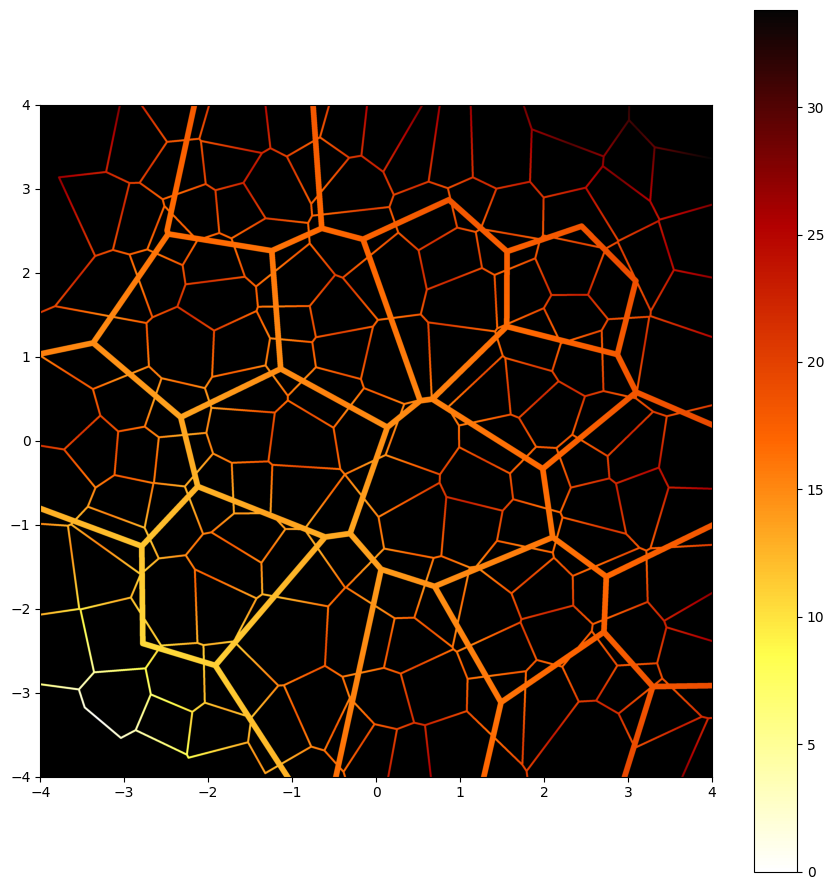

/tmp/ipykernel_2698/2811192997.py:401: RuntimeWarning: overflow encountered in square
  grad_norm = np.sqrt(Tx**2 + Ty**2)


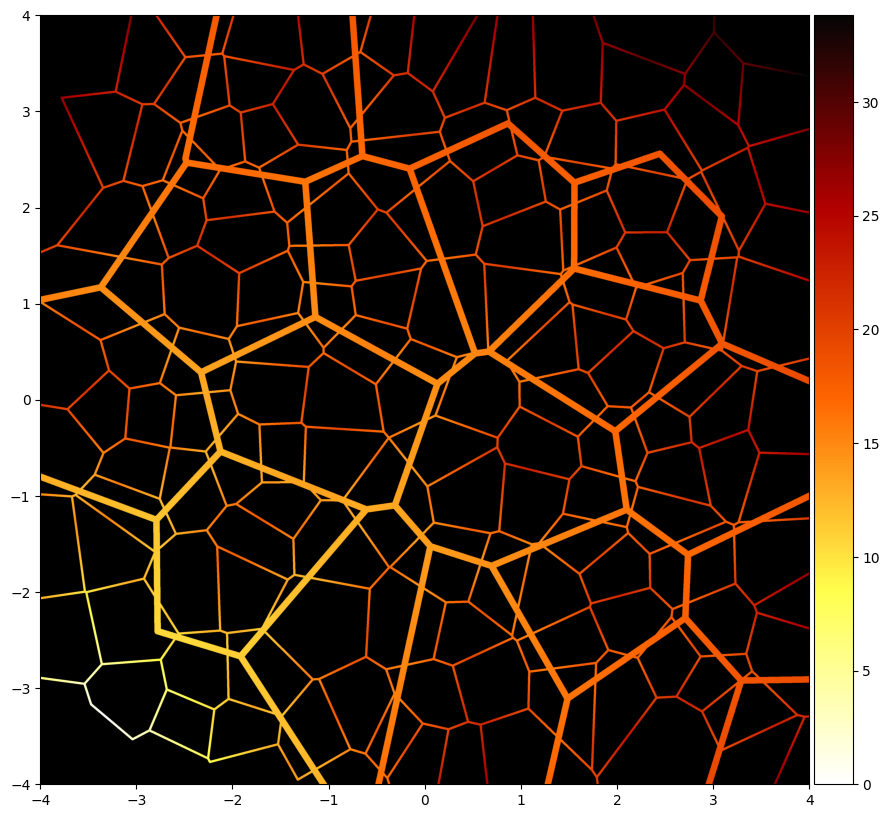

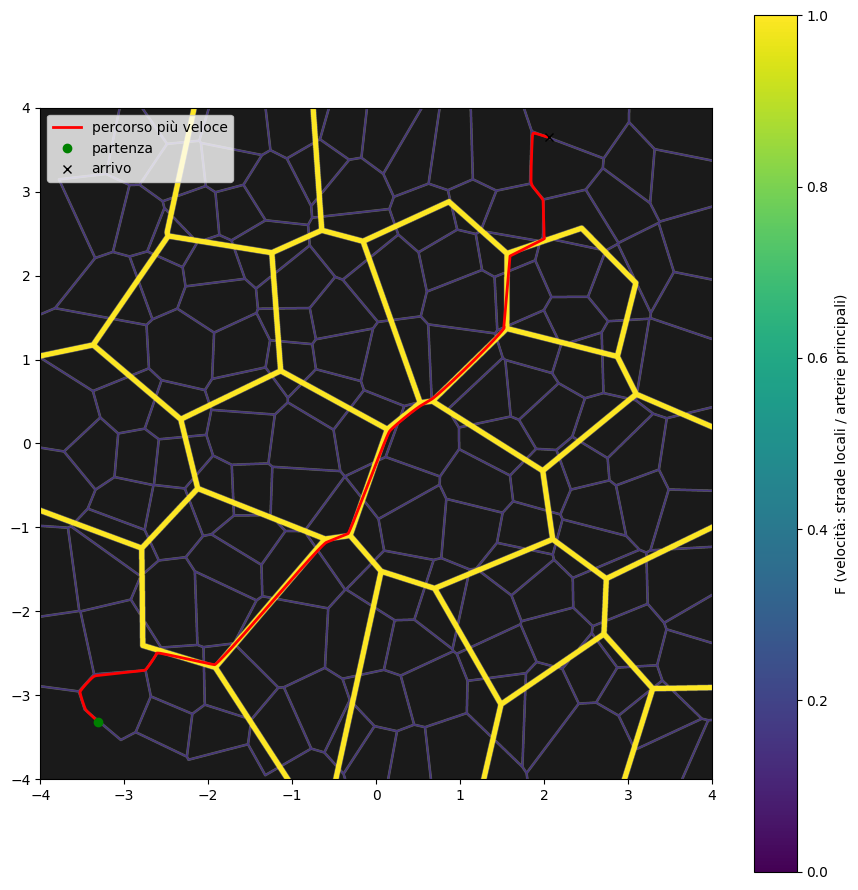

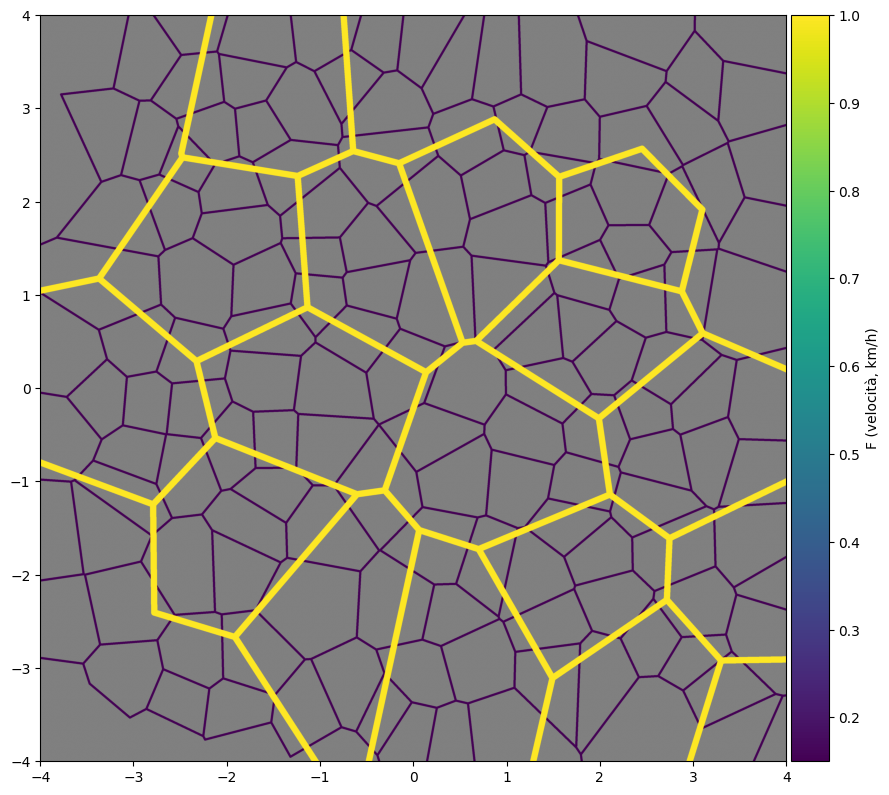

In [ ]:
# ==============================================================================
# VERSIONE FIM JACOBI SENZA LISTA PARALLELIZZATA IN RAWKERNEL SU MAPPA STRADALE
# (rete stradale organica generata da Voronoi, dominio quadrato)
# ==============================================================================

#------------------  LIBRERIE --------------------------------------------------

import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
import numpy.ma as ma
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive
from scipy.ndimage import distance_transform_edt
from scipy.spatial import Voronoi, cKDTree

#------------------  DISCRETIZZAZIONE DEL DOMINIO ------------------------------

# dominio quadrato 4000x4000

nx = 4000
ny = 4000
nRows = ny
nCols = nx
sidex = 4
sidey = 4
domain = [-sidex, sidex, -sidey, sidey]
x = np.linspace(domain[0], domain[1], nx)
y = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[X, Y] = np.meshgrid(x, y)
eps = 1e-6


#------------------  CAMPO DI VELOCITA' (RETE STRADALE ORGANICA, VORONOI) ------

h = dx


def sample_points_min_dist(nx, ny, n_points, min_dist, seed):
    """
    Campiona n_points punti nel dominio [0,nx]x[0,ny] con una distanza minima
    reciproca min_dist (campionamento tipo 'blue noise'), tramite dart-throwing
    accelerato con un KD-tree per il controllo delle distanze.
    """
    rng = np.random.default_rng(seed)
    pts = np.empty((0, 2))
    attempts = 0
    max_attempts = n_points * 300

    while len(pts) < n_points and attempts < max_attempts:
        cand = rng.uniform([0, 0], [nx, ny], size=(1, 2))
        attempts += 1
        if len(pts) == 0:
            pts = cand
            continue
        tree = cKDTree(pts)
        d, _ = tree.query(cand)
        if d[0] >= min_dist:
            pts = np.vstack([pts, cand])

    return pts


def voronoi_edges(points):
    """Restituisce la lista dei segmenti (bordi finiti) del diagramma di Voronoi dei punti dati."""
    vor = Voronoi(points)
    segments = []
    for i1, i2 in vor.ridge_vertices:
        if i1 == -1 or i2 == -1:
            continue   # scarta i bordi che vanno all'infinito
        segments.append((vor.vertices[i1], vor.vertices[i2]))
    return segments


def rasterize_segments(F, segments, width, value, nx, ny):
    """Disegna su F un insieme di segmenti (strade) con una certa larghezza e valore di F."""
    half_w = width / 2.0
    for (p0, p1) in segments:
        x0, y0 = p0
        x1, y1 = p1

        seg_len = np.hypot(x1 - x0, y1 - y0)
        if seg_len < 1e-6:
            continue

        pad = int(width) + 2
        xmin = int(max(min(x0, x1) - pad, 0))
        xmax = int(min(max(x0, x1) + pad, nx))
        ymin = int(max(min(y0, y1) - pad, 0))
        ymax = int(min(max(y0, y1) + pad, ny))
        if xmax <= xmin or ymax <= ymin:
            continue

        yy_local, xx_local = np.mgrid[ymin:ymax, xmin:xmax]
        yy_local = yy_local.astype(np.float32)
        xx_local = xx_local.astype(np.float32)

        dxs, dys = x1 - x0, y1 - y0
        t = ((xx_local - x0) * dxs + (yy_local - y0) * dys) / (dxs**2 + dys**2)
        t = np.clip(t, 0.0, 1.0)
        proj_x = x0 + t * dxs
        proj_y = y0 + t * dys
        dist = np.hypot(xx_local - proj_x, yy_local - proj_y)

        mask = dist <= half_w
        F[ymin:ymax, xmin:xmax][mask] = value


def find_nearest_walkable(F, iy, ix, max_radius=500):
    """Se (iy,ix) cade dentro un edificio, cerca la cella percorribile più vicina."""
    if np.isfinite(F[iy, ix]):
        return iy, ix
    ny_, nx_ = F.shape
    for r in range(1, max_radius):
        y0, y1 = max(iy - r, 0), min(iy + r + 1, ny_)
        x0, x1 = max(ix - r, 0), min(ix + r + 1, nx_)
        sub = F[y0:y1, x0:x1]
        idx = np.argwhere(np.isfinite(sub))
        if idx.size > 0:
            fy, fx = idx[0]
            return y0 + fy, x0 + fx
    raise RuntimeError("nessuna cella percorribile trovata entro max_radius")


def build_city_F_voronoi(nx, ny,
                          n_main_points=25, main_min_dist=600,
                          n_local_points=450, local_min_dist=80,
                          highway_width=34, street_width=12,
                          f_street=0.30, f_highway=1.0,
                          seed=0):
    """
    Costruisce una mappa stradale organica dove SOLO le strade sono
    percorribili; tutto il resto (l'interno degli isolati) è impenetrabile:
      1) F = inf ovunque (blocchi/edifici tra le strade: muro);
      2) rete di strade locali = bordi del Voronoi di molti punti fitti
         (F = f_street, strette e lente);
      3) rete di arterie principali = bordi del Voronoi di pochi punti radi
         (F = f_highway, più larghe e più veloci), sovrapposta sopra tutto.
    """
    F = np.full((ny, nx), np.inf, dtype=np.float32)

    local_pts = sample_points_min_dist(nx, ny, n_local_points, local_min_dist, seed=seed + 1)
    local_edges = voronoi_edges(local_pts)
    rasterize_segments(F, local_edges, street_width, f_street, nx, ny)

    main_pts = sample_points_min_dist(nx, ny, n_main_points, main_min_dist, seed=seed + 2)
    main_edges = voronoi_edges(main_pts)
    rasterize_segments(F, main_edges, highway_width, f_highway, nx, ny)

    return F

F = build_city_F_voronoi(
    nx, ny,
    n_main_points=25, main_min_dist=600,
    n_local_points=150,      # erano 450: meno punti = meno bordi di Voronoi = meno stradine
    local_min_dist=180,      # era 80: distanza minima maggiore = isolati più grandi e radi
    highway_width=34, street_width=12,
    f_street=0.15, f_highway=1.0,
    seed=0
)

wall_mask = np.isinf(F)   # True sugli edifici, False su spazio aperto e strade

#------------------  FASCIA DI SICUREZZA AI MURI -------------------------------

def inflate_walls_smooth(F, wall_mask, margin_cells, penalty_factor):
    F_smooth = F.copy()
    dist_to_wall = distance_transform_edt(~wall_mask)   # distanza in celle dal muro più vicino
    ramp = np.clip(dist_to_wall / margin_cells, 0.0, 1.0)
    F_ramped = penalty_factor + (1.0 - penalty_factor) * ramp
    F_smooth[~wall_mask] = F_ramped[~wall_mask]
    return F_smooth

F_safe = F #non uso F_safe per fare il confronto con Dijkstra

# ==============================================================================
# CALCOLO ICONALE PARALLELIZZATO IN RAWKERNEL
# ==============================================================================

#------------------  SORGENTE (partenza, agganciata alla cella percorribile) ---

iy0_req, ix0_req = 10, 10
iy0, ix0 = find_nearest_walkable(F, iy0_req, ix0_req)

T = np.full(X.shape, 1e30, dtype=np.float32)
T[iy0, ix0] = 0.0

#------------------  UPLOAD CPU -> GPU -----------------------------------------

T_gpu = cp.array(T)
F_gpu = cp.array(F_safe)

#------------------ GODUNOV 1 --------------------------------------------------

godunov_code = godunov_code = r'''
extern "C" __global__
void godunov_update_full(
    const float* T,
    const float* F,
    float*       T_new,
    int          nRows,
    int          nCols,
    float        h
) {

    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= nRows * nCols) return;

    int r = idx / nCols;
    int c = idx % nCols;

    // nodo muro
    float f = F[idx];
    if (isinf(f)) {
        T_new[idx] = 1e30f;
        return;
    }

    // nodo sorgente: non toccare mai
    if (T[idx] == 0.0f) {
        T_new[idx] = 0.0f;
        return;
    }

    float left, right, down, up;

    if (c - 1 < 0 || isinf(F[r * nCols + (c-1)]))
        left = 1e30f;
    else
        left = T[r * nCols + (c-1)];

    if (c + 1 >= nCols || isinf(F[r * nCols + (c+1)]))
        right = 1e30f;
    else
        right = T[r * nCols + (c+1)];

    if (r - 1 < 0 || isinf(F[(r-1) * nCols + c]))
        down = 1e30f;
    else
        down = T[(r-1) * nCols + c];

    if (r + 1 >= nRows || isinf(F[(r+1) * nCols + c]))
        up = 1e30f;
    else
        up = T[(r+1) * nCols + c];

    float Txmin = fminf(left, right);
    float Tymin = fminf(down, up);

    float a = fminf(Txmin, Tymin);
    float b = fmaxf(Txmin, Tymin);

    float rhs = h / f;

    float result;
    if ((b - a) < rhs) {
        float disc = 2.0f * rhs*rhs - (a - b)*(a - b);
        if (disc < 0.0f) disc = 0.0f;
        result = (a + b + sqrtf(disc)) / 2.0f;
    } else {
        result = a + rhs;
    }

    T_new[idx] = result;
}
'''

godunov_ker = cp.RawKernel(godunov_code, 'godunov_update_full')


#------------------  AGGIORNAMENTO FIM JACOBI ----------------------------------

#  versione ottimizzata: controlla ogni 25 passi anzichè ad ogni passo, per
#  allegerire il carico computazionale

def FIM_senzaLista_raw(T, F, check_every=25):
    threads_per_block = 256
    n = nRows * nCols
    blocchi = (n + threads_per_block - 1) // threads_per_block

    # due buffer fissi: eliminano la copy() e l'allocazione ripetuta ad ogni iterazione
    T_a = T.ravel().copy()
    T_b = cp.empty(n, dtype=cp.float32)
    T_new = cp.empty(n, dtype=cp.float32)
    F_flat = F.ravel()

    cur, nxt = T_a, T_b
    it = 0

    while True:
        godunov_ker(
            (blocchi,), (threads_per_block,),
            (cur, F_flat, T_new,
             cp.int32(nRows), cp.int32(nCols), cp.float32(h))
        )

        cp.minimum(cur, T_new, out=nxt)  # scrive direttamente nel buffer esistente

        # il controllo di convergenza (che forza sync GPU->CPU) viene fatto
        # solo ogni check_every iterazioni, non ad ogni passo
        if it % check_every == 0:
            maxdiff = float(cp.max(cp.abs(cur - nxt)))
            if maxdiff < eps:
                cur = nxt
                break

        cur, nxt = nxt, cur
        it += 1

    return cur.reshape(nRows, nCols)

#------------------  SOLVE AND UPLOAD GPU -> CPU -------------------------------

T_final_gpu = FIM_senzaLista_raw(T_gpu, F_gpu)

# ── torna su CPU per il plot ──────────────────────────────────────────────────
T_final = cp.asnumpy(T_final_gpu)

#------------------  STAMPA DEI RISULTATI --------------------------------------

# maschera i muri (e qualunque cella rimasta a sentinella) prima del plot
T_masked = ma.masked_where(T_final >= 1e29, T_final)

fig, ax = plt.subplots(figsize=(9, 9))
im = ax.imshow(T_masked, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')
plt.colorbar(im, ax=ax)

stops = np.array([
    [1.00, 1.00, 1.00],
    [1.00, 1.00, 0.30],
    [1.00, 0.40, 0.00],
    [0.70, 0.00, 0.00],
    [0.02, 0.02, 0.02],
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)
cmap2.set_bad(color='black')   # colore per le celle mascherate (gli edifici)
im.set_cmap(cmap2)
plt.tight_layout()
plt.show()


# ==============================================================================
# CALCOLO DEI RAGGI (PERCORSO PIU' VELOCE)
# ==============================================================================

#------------------ DISCRETIZZAZIONE DEL GRADIENTE -----------------------------

def Gradient_FD(T_final, F, dx, dy):
    wall_mask = np.isinf(F)
    nRows, nCols = T_final.shape

    Tx = np.zeros_like(T_final)
    Ty = np.zeros_like(T_final)

    # --- Derivata rispetto a x (colonne) ---
    valid = ~wall_mask

    left_ok  = np.zeros_like(valid)
    right_ok = np.zeros_like(valid)
    left_ok[:, 1:]  = valid[:, :-1]   # vicino a sinistra è valido
    right_ok[:, :-1] = valid[:, 1:]   # vicino a destra è valido

    T_left  = np.full_like(T_final, np.nan)
    T_right = np.full_like(T_final, np.nan)
    T_left[:, 1:]  = T_final[:, :-1]
    T_right[:, :-1] = T_final[:, 1:]

    both_x = left_ok & right_ok
    only_left_x  = left_ok & ~right_ok    # solo sinistra disponibile → backward diff
    only_right_x = right_ok & ~left_ok    # solo destra disponibile → forward diff

    Tx[both_x] = (T_right[both_x] - T_left[both_x]) / (2 * dx)
    Tx[only_right_x] = (T_right[only_right_x] - T_final[only_right_x]) / dx
    Tx[only_left_x]  = (T_final[only_left_x] - T_left[only_left_x]) / dx
    # entrambi i vicini muro (o cella stessa muro) → Tx resta 0

    # --- Derivata rispetto a y (righe) ---
    down_ok = np.zeros_like(valid)
    up_ok   = np.zeros_like(valid)
    down_ok[1:, :] = valid[:-1, :]    # vicino sotto è valido
    up_ok[:-1, :]  = valid[1:, :]     # vicino sopra è valido

    T_down = np.full_like(T_final, np.nan)
    T_up   = np.full_like(T_final, np.nan)
    T_down[1:, :] = T_final[:-1, :]
    T_up[:-1, :]  = T_final[1:, :]

    both_y = down_ok & up_ok
    only_down_y = down_ok & ~up_ok
    only_up_y   = up_ok & ~down_ok

    Ty[both_y] = (T_up[both_y] - T_down[both_y]) / (2 * dy)
    Ty[only_up_y]   = (T_up[only_up_y] - T_final[only_up_y]) / dy
    Ty[only_down_y] = (T_final[only_down_y] - T_down[only_down_y]) / dy

    # --- Rinormalizzazione secondo l'eikonale: |grad T| = 1/F ---
    grad_norm = np.sqrt(Tx**2 + Ty**2)
    scale = np.zeros_like(grad_norm)
    finite_F = np.isfinite(F) & (grad_norm > 1e-12)
    scale[finite_F] = 1.0 / (F[finite_F] * grad_norm[finite_F])

    Tx = np.where(finite_F, Tx * scale, 0.0)
    Ty = np.where(finite_F, Ty * scale, 0.0)

    # azzera esplicitamente le celle muro
    Tx[wall_mask] = 0.0
    Ty[wall_mask] = 0.0

    return Tx, Ty

Tx = np.zeros_like(T_final)
Ty = np.zeros_like(T_final)

Tx, Ty = Gradient_FD(T_final, F, dx, dy)

#------------------  ADATTAMENTO DEI MURI --------------------------------------

def fill_wall_nans(field, wall_mask):
    """Sostituisce i valori nelle celle muro con quelli della cella valida più vicina."""
    # indici della cella valida più vicina per ogni punto della griglia
    idx = distance_transform_edt(wall_mask, return_distances=False, return_indices=True)
    return field[tuple(idx)]

#------------------  INTERPOLAZIONE BILINEARE ----------------------------------

wall_mask = np.isinf(F)

Tx_filled = fill_wall_nans(Tx, wall_mask)
Ty_filled = fill_wall_nans(Ty, wall_mask)

Tx_interp = RegularGridInterpolator((y, x), Tx_filled, method='linear',
                                     bounds_error=False, fill_value=None)
Ty_interp = RegularGridInterpolator((y, x), Ty_filled, method='linear',
                                     bounds_error=False, fill_value=None)


def grad_at(pt, Tx_interp, Ty_interp):
    """pt = (px, py) in coordinate cartesiane."""
    px, py = pt
    point = np.array([[py, px]])  # RegularGridInterpolator vuole shape (n_points, n_dims)
    gx = Tx_interp(point)[0]
    gy = Ty_interp(point)[0]
    if not (np.isfinite(gx) and np.isfinite(gy)):
        return np.array([0.0, 0.0])
    return np.array([gx, gy])

#------------------  INTEGRAZIONE RK4 ------------------------------------------

def trace_ray_rk4(start_pt, Tx_interp, Ty_interp, source_pt, ds, max_steps):
    """
    Integra all'indietro seguendo -grad(T) a partire da start_pt (destinazione)
    fino ad avvicinarsi a source_pt (partenza). Il percorso risultante è il
    cammino a tempo minimo, cioè il "percorso più veloce" del navigatore.
    """
    pt = np.array(start_pt, dtype=float)
    ray = [pt.copy()]

    for step in range(max_steps):

        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
          break

        k1 = -grad_at(pt, Tx_interp, Ty_interp)
        if np.linalg.norm(k1) < 1e-12:
            break
        k2 = -grad_at(pt + 0.5*ds*k1, Tx_interp, Ty_interp)
        k3 = -grad_at(pt + 0.5*ds*k2, Tx_interp, Ty_interp)
        k4 = -grad_at(pt + ds*k3, Tx_interp, Ty_interp)

        dpt = (k1 + 2*k2 + 2*k3 + k4) / 6.0
        pt_new = pt + ds * dpt

        ray.append(pt_new.copy())

        # criterio di arresto: raggio arrivato vicino alla sorgente
        if np.linalg.norm(pt_new - np.array(source_pt)) < ds:
            ray.append(np.array(source_pt, dtype=float))
            break

        # criterio di stagnazione (raggio bloccato, es. contro un edificio)
        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
            break

        pt = pt_new

    return np.array(ray)

#------------------  CALCOLO DEL PERCORSO ALL'INDIETRO -------------------------

# coordinate cartesiane del punto di partenza
source_pt = (x[ix0], y[iy0])

# punto di arrivo: angolo opposto, agganciato alla cella percorribile più vicina
iy_exit_req, ix_exit_req = ny - 10, nx - 800
iy_exit, ix_exit = find_nearest_walkable(F, iy_exit_req, ix_exit_req)

exit_pt = (x[ix_exit], y[iy_exit])

ds = dx  # passo di integrazione
max_steps = 20000

ray = trace_ray_rk4(exit_pt, Tx_interp, Ty_interp, source_pt, ds, max_steps)


#------------------  STAMPA DEI RISULTATI --------------------------------------

from mpl_toolkits.axes_grid1 import make_axes_locatable

T_masked = ma.masked_where(T_final >= 1e29, T_final)

fig, ax = plt.subplots(figsize=(9, 9))
im = ax.imshow(T_masked, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax)

stops = np.array([
    [1.00, 1.00, 1.00],
    [1.00, 1.00, 0.30],
    [1.00, 0.40, 0.00],
    [0.70, 0.00, 0.00],
    [0.02, 0.02, 0.02],
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)
cmap2.set_bad(color='black')
im.set_cmap(cmap2)
plt.tight_layout()
plt.show()
# (opzionale) visualizzazione della mappa stradale F stessa, con il percorso
fig2, ax2 = plt.subplots(figsize=(9, 9))
F_display = ma.masked_where(np.isinf(F), F)
im2 = ax2.imshow(F_display, extent=[x.min(), x.max(), y.min(), y.max()],
                  origin='lower', aspect='equal', cmap='viridis', vmin=0.0, vmax=1.0)
ax2.imshow(ma.masked_where(~np.isinf(F), np.ones_like(F)),
           extent=[x.min(), x.max(), y.min(), y.max()],
           origin='lower', aspect='equal', cmap='gray_r', vmin=0, vmax=1, alpha=0.9)
plt.colorbar(im2, ax=ax2, label='F (velocità: strade locali / arterie principali)')
ax2.plot(ray[:, 0], ray[:, 1], color='red', linewidth=2, label='percorso più veloce')
ax2.plot(*source_pt, 'go', label='partenza')
ax2.plot(*exit_pt, 'kx', label='arrivo')
ax2.legend()
plt.tight_layout()
plt.show()

#------------------  VISUALIZZAZIONE DEL SOLO CAMPO DI VELOCITA' F -------------


fig_f, ax_f = plt.subplots(figsize=(9, 9))
F_display = ma.masked_where(np.isinf(F), F)
im_f = ax_f.imshow(F_display, extent=[x.min(), x.max(), y.min(), y.max()],
                    origin='lower', aspect='equal', cmap='viridis')
im_f.cmap.set_bad(color='gray')   # muri/edifici in nero

divider = make_axes_locatable(ax_f)
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im_f, cax=cax, label='F (velocità, km/h)')

plt.tight_layout()
plt.show()

Tempo Dijkstra (grafo sparso, esatto sulla griglia): 33.872757
Tempo FIM (eikonale, T_final all'arrivo):            27.942709
Differenza relativa:                                  17.507 %

---- Tempo integrato lungo la traiettoria (ds/F), confronto omogeneo ----
Percorso FIM (RK4):      27.697673
Percorso Dijkstra:       33.872757
-> il percorso del FIM risulta più veloce.


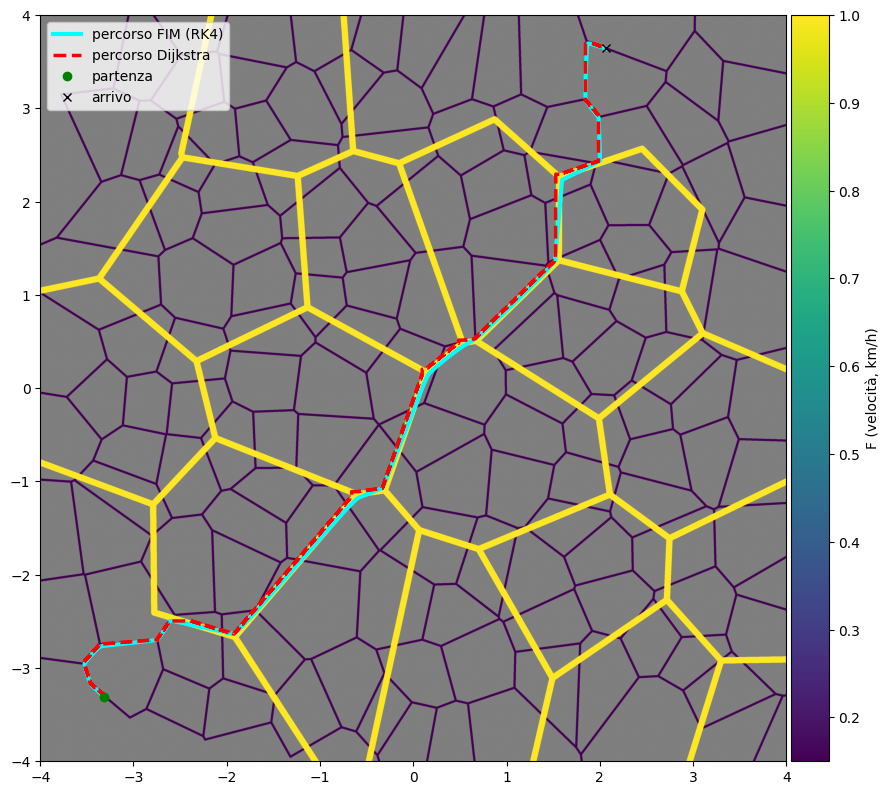

In [ ]:
# IMPORTANTE!! ESEGUIRE PRIMA LA CELLA SOPRA E POI QUESTA

# ==============================================================================
# VALIDAZIONE DEL RISULTATO FIM TRAMITE DIJKSTRA (scipy.sparse.csgraph)
# ==============================================================================

# Idea: costruire un grafo sparso sulla stessa griglia usata dal FIM

import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra
from scipy.interpolate import RegularGridInterpolator
import matplotlib.pyplot as plt
import numpy.ma as ma

#------------------  COSTRUZIONE DEL GRAFO SPARSO DALLA GRIGLIA F --------------

def build_grid_graph(F, dx, dy):
    """
    Costruisce il grafo pesato sulla griglia: un nodo per ogni cella
    percorribile (F finito), un arco tra celle 4-adiacenti (stessa
    connettività dello stencil usato nel kernel Godunov), con peso pari al
    TEMPO per percorrere quell'arco: tempo = distanza / velocità.

    Restituisce:
      graph      : scipy.sparse.csr_matrix (grafo pesato, tempi di percorrenza)
      node_id    : array (ny, nx) di interi, node_id[iy, ix] = indice del nodo
                   nel grafo (-1 se la cella è muro/non percorribile)
      valid_mask : array booleano (ny, nx), True dove la cella è percorribile
    """
    ny, nx = F.shape
    valid_mask = np.isfinite(F)

    # numerazione dei nodi validi
    node_id = -np.ones((ny, nx), dtype=np.int64)
    node_id[valid_mask] = np.arange(valid_mask.sum())
    n_nodes = valid_mask.sum()

    rows, cols, weights = [], [], []

    iy, ix = np.nonzero(valid_mask)

    # arco verso destra (ix+1): esiste se anche il vicino è valido
    has_right = (ix + 1 < nx)
    iy_r = iy[has_right]
    ix_r = ix[has_right]
    valid_r = valid_mask[iy_r, ix_r + 1]
    iy_r = iy_r[valid_r]
    ix_r = ix_r[valid_r]

    src = node_id[iy_r, ix_r]
    dst = node_id[iy_r, ix_r + 1]
    f_avg = 0.5 * (F[iy_r, ix_r] + F[iy_r, ix_r + 1])
    w = dx / f_avg
    rows += [src, dst]; cols += [dst, src]; weights += [w, w]

    # arco verso l'alto (iy+1): esiste se anche il vicino è valido
    has_up = (iy + 1 < ny)
    iy_u = iy[has_up]
    ix_u = ix[has_up]
    valid_u = valid_mask[iy_u + 1, ix_u]
    iy_u = iy_u[valid_u]
    ix_u = ix_u[valid_u]

    src = node_id[iy_u, ix_u]
    dst = node_id[iy_u + 1, ix_u]
    f_avg = 0.5 * (F[iy_u, ix_u] + F[iy_u + 1, ix_u])
    w = dy / f_avg
    rows += [src, dst]; cols += [dst, src]; weights += [w, w]

    rows = np.concatenate(rows)
    cols = np.concatenate(cols)
    weights = np.concatenate(weights)

    graph = csr_matrix((weights, (rows, cols)), shape=(n_nodes, n_nodes))
    return graph, node_id, valid_mask


#------------------  RISOLUZIONE DI DIJKSTRA SORGENTE -> ARRIVO ----------------

def run_dijkstra(F, dx, dy, iy0, ix0, iy1, ix1):
    """
    Risolve Dijkstra dalla cella (iy0,ix0) alla cella (iy1,ix1) sul grafo
    costruito da build_grid_graph. Restituisce il tempo totale e il percorso
    come lista di indici (iy, ix) di griglia.
    """
    graph, node_id, valid_mask = build_grid_graph(F, dx, dy)

    src_node = node_id[iy0, ix0]
    dst_node = node_id[iy1, ix1]
    if src_node < 0 or dst_node < 0:
        raise ValueError("Sorgente o arrivo cadono su una cella non percorribile (F=inf).")

    dist, predecessors = dijkstra(
        graph, directed=False, indices=src_node,
        return_predecessors=True
    )

    T_dijkstra = dist[dst_node]
    if not np.isfinite(T_dijkstra):
        raise RuntimeError("Nessun percorso trovato tra sorgente e arrivo (grafo disconnesso).")

    # ricostruzione del cammino risalendo i predecessori
    path_nodes = [dst_node]
    cur = dst_node
    while cur != src_node:
        cur = predecessors[cur]
        path_nodes.append(cur)
    path_nodes = path_nodes[::-1]

    # da indice nodo a indici di griglia (iy, ix)
    ny, nx = F.shape
    iy_all, ix_all = np.nonzero(valid_mask)
    # inverto la numerazione: node_id -> (iy, ix)
    inv_iy = np.full(node_id.max() + 1, -1, dtype=np.int64)
    inv_ix = np.full(node_id.max() + 1, -1, dtype=np.int64)
    inv_iy[node_id[valid_mask]] = iy_all
    inv_ix[node_id[valid_mask]] = ix_all

    path_iy = inv_iy[path_nodes]
    path_ix = inv_ix[path_nodes]

    return T_dijkstra, path_iy, path_ix


#------------------  ESECUZIONE E CONFRONTO CON IL FIM -------------------------

# NB: richiede che nello script FIM siano già definiti F, dx, dy, x, y,
# iy0, ix0 (sorgente) e iy_exit, ix_exit (arrivo), oltre a T_final e ray
# già calcolati con il solver FIM/RawKernel.

T_dijkstra, path_iy, path_ix = run_dijkstra(F, dx, dy, iy0, ix0, iy_exit, ix_exit)

path_x = x[path_ix]
path_y = y[path_iy]

T_fim_at_exit = T_final[iy_exit, ix_exit]

print(f"Tempo Dijkstra (grafo sparso, esatto sulla griglia): {T_dijkstra:.6f}")
print(f"Tempo FIM (eikonale, T_final all'arrivo):            {T_fim_at_exit:.6f}")
print(f"Differenza relativa:                                  "
      f"{abs(T_dijkstra - T_fim_at_exit) / T_dijkstra * 100:.3f} %")

#------------------  TEMPO INTEGRATO LUNGO CIASCUN PERCORSO ---------------------
#
# Oltre ai tempi "dichiarati" da ciascun metodo (T_final del FIM, dist di
# Dijkstra), calcoliamo il tempo REALE di percorrenza di ciascuna traiettoria
# integrando ds/F lungo il cammino stesso. Questo permette di confrontare
# in modo omogeneo i due percorsi indipendentemente da come sono stati
# generati, e di verificare quale sia effettivamente il più veloce.

F_filled = fill_wall_nans(F, np.isinf(F))   # F esteso anche sui muri, per interpolare senza inf
F_interp = RegularGridInterpolator((y, x), F_filled, method='linear',
                                    bounds_error=False, fill_value=None)


def integrate_travel_time(path_x, path_y, F_interp):
    """
    Integra il tempo di percorrenza lungo un percorso poligonale (path_x,
    path_y), usando la velocità locale F interpolata al punto medio di ogni
    segmento: tempo_segmento = lunghezza_segmento / F(punto_medio).
    """
    path_x = np.asarray(path_x)
    path_y = np.asarray(path_y)

    seg_dx = np.diff(path_x)
    seg_dy = np.diff(path_y)
    seg_len = np.hypot(seg_dx, seg_dy)

    mid_x = 0.5 * (path_x[:-1] + path_x[1:])
    mid_y = 0.5 * (path_y[:-1] + path_y[1:])
    mid_pts = np.column_stack([mid_y, mid_x])   # RegularGridInterpolator vuole (y, x)

    f_mid = F_interp(mid_pts)
    f_mid = np.clip(f_mid, 1e-6, None)   # evita divisioni per zero/negativo da interpolazione

    seg_time = seg_len / f_mid
    return float(np.sum(seg_time)), np.concatenate([[0.0], np.cumsum(seg_time)])


T_ray_integrated, _ = integrate_travel_time(ray[:, 0], ray[:, 1], F_interp)
T_dijkstra_integrated, _ = integrate_travel_time(path_x, path_y, F_interp)

print()
print("---- Tempo integrato lungo la traiettoria (ds/F), confronto omogeneo ----")
print(f"Percorso FIM (RK4):      {T_ray_integrated:.6f}")
print(f"Percorso Dijkstra:       {T_dijkstra_integrated:.6f}")
if T_ray_integrated < T_dijkstra_integrated:
    print("-> il percorso del FIM risulta più veloce.")
elif T_dijkstra_integrated < T_ray_integrated:
    print("-> il percorso di Dijkstra risulta più veloce.")
else:
    print("-> i due percorsi risultano equivalenti in tempo.")

#------------------  PLOT DI CONFRONTO ------------------------------------------

fig, ax = plt.subplots(figsize=(9, 9))
F_display = ma.masked_where(np.isinf(F), F)
im = ax.imshow(F_display, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal', cmap='viridis')
im.cmap.set_bad(color='#7f7f7f')   # grigio chiaro per i quartieri non attraversabili

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax, label='F (velocità, km/h)')

ax.plot(ray[:, 0], ray[:, 1], color='cyan', linewidth=3, label='percorso FIM (RK4)')
ax.plot(path_x, path_y, color='red', linewidth=2.5, linestyle='--', label='percorso Dijkstra')
ax.plot(x[ix0], y[iy0], 'go', label='partenza')
ax.plot(x[ix_exit], y[iy_exit], 'kx', label='arrivo')
ax.legend()
plt.tight_layout()
plt.show()

# ==============================================================================
# (OPZIONALE) EXPORT DI UN GRAFO SOTTO-CAMPIONATO COME EDGE LIST PER TOOL ONLINE
# ==============================================================================
#
# Se il tuo professore vuole proprio vedere l'uso di un tool online, alla
# risoluzione piena non è possibile (16M nodi). Questa funzione sotto-
# campiona la griglia di un fattore 'stride' (es. 1 nodo ogni 20 celle) e
# scrive una edge list "nodo_i,nodo_j,peso" in un CSV, molto più leggera di
# una matrice piena e accettata dalla maggior parte dei tool online.

def export_edge_list_downsampled(F, dx, dy, stride, filename="grafo_dijkstra.csv"):
    F_small = F[::stride, ::stride]
    dx_small = dx * stride
    dy_small = dy * stride

    graph, node_id, valid_mask = build_grid_graph(F_small, dx_small, dy_small)
    graph_coo = graph.tocoo()

    with open(filename, "w") as f:
        f.write("source,target,weight\n")
        for i, j, w in zip(graph_coo.row, graph_coo.col, graph_coo.data):
            if i < j:   # il grafo è simmetrico: scrivo ogni arco una sola volta
                f.write(f"{i},{j},{w:.6f}\n")

    n_nodes = int(valid_mask.sum())
    n_edges = graph_coo.nnz // 2
    print(f"Grafo sotto-campionato (stride={stride}): {n_nodes} nodi, {n_edges} archi -> {filename}")


# esempio di utilizzo (decommenta e scegli uno stride che dia qualche
# migliaio di nodi al massimo, gestibile da un tool online):
#
# export_edge_list_downsampled(F, dx, dy, stride=25, filename="grafo_dijkstra.csv")

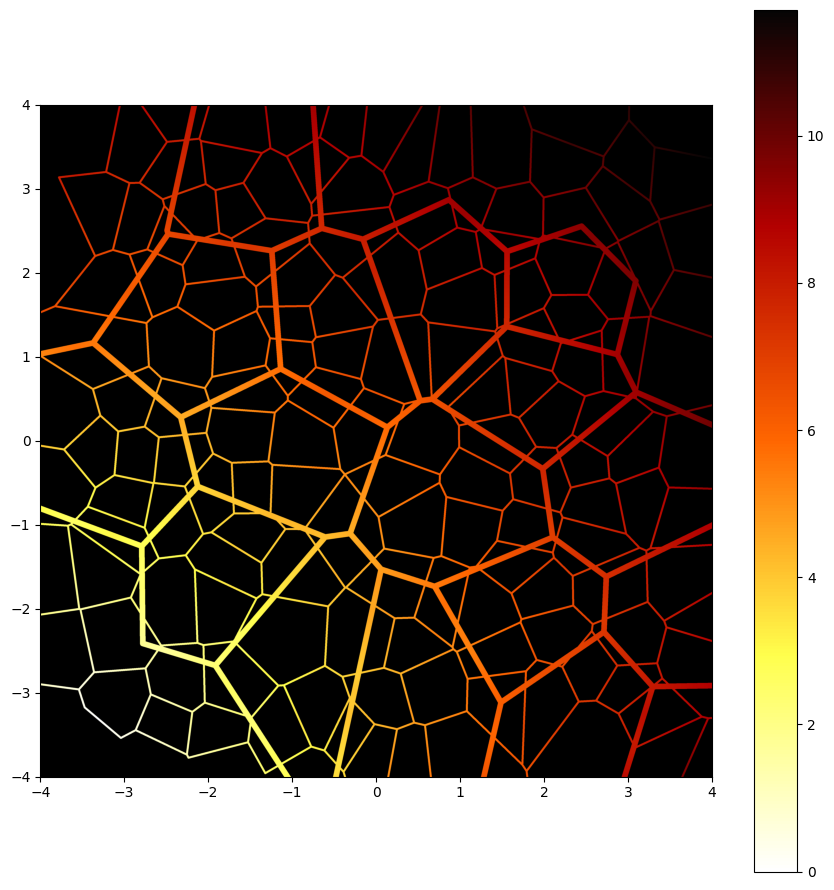

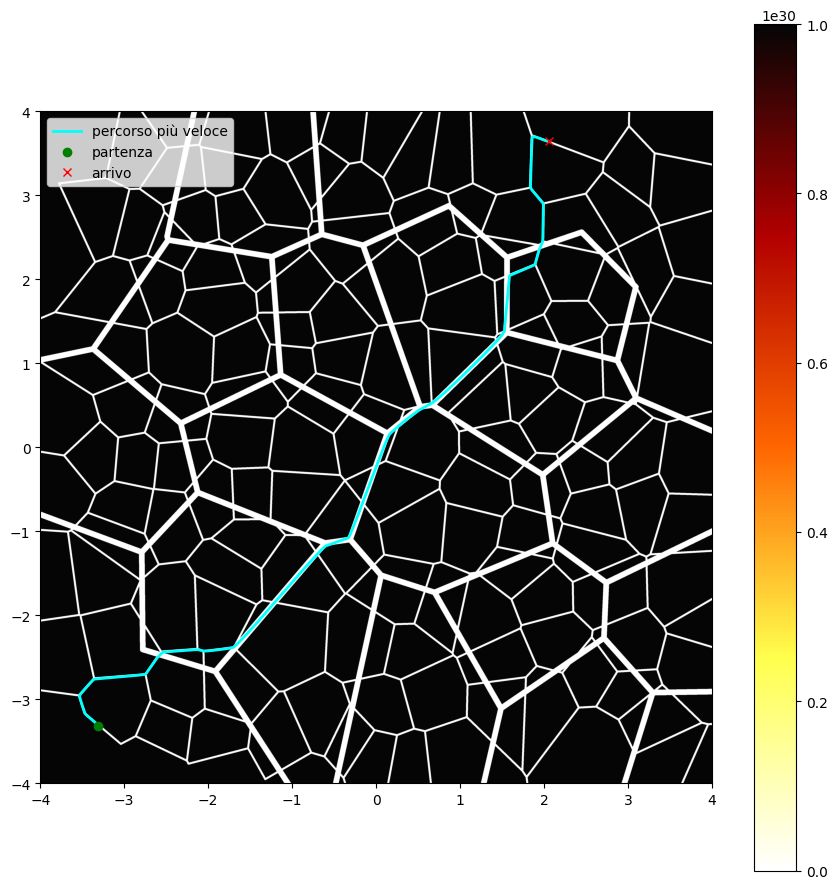

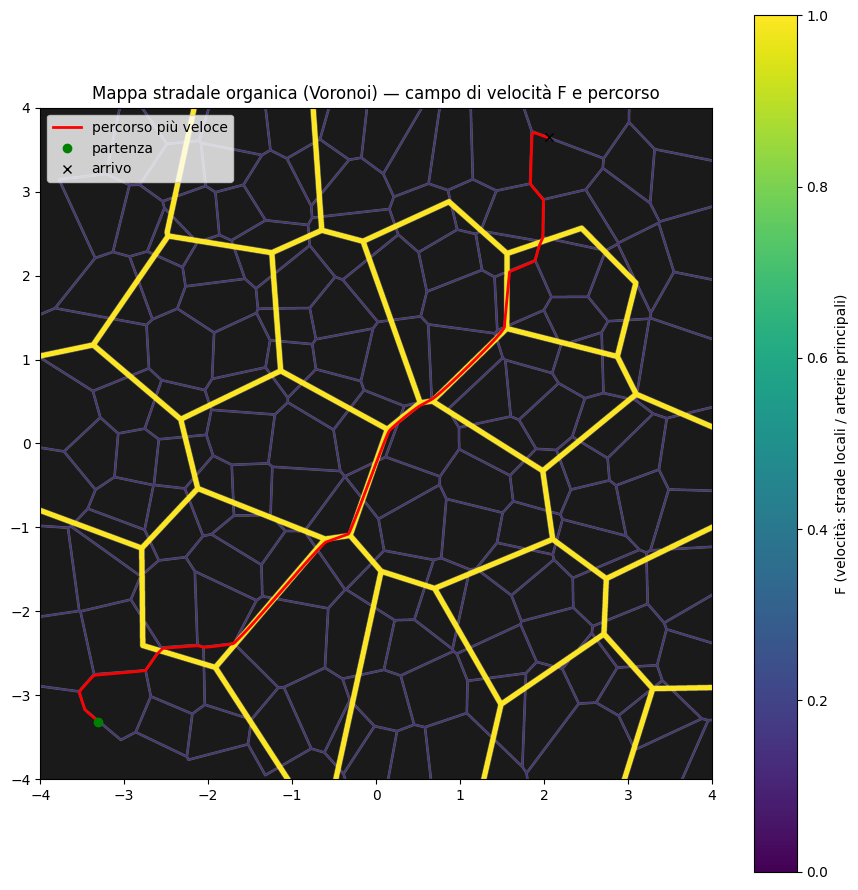

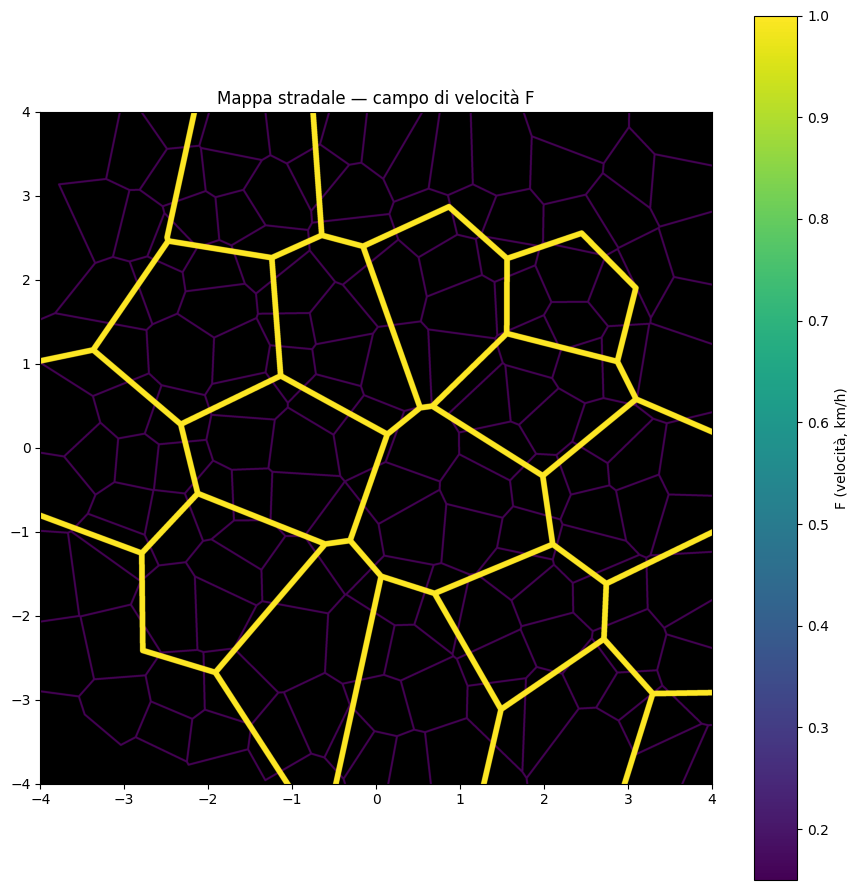

In [ ]:
# ==============================================================================
# VERSIONE FIM JACOBI SENZA LISTA PARALLELIZZATA IN RAWKERNEL SU MAPPA STRADALE
# (rete stradale organica generata da Voronoi, dominio quadrato)
# ==============================================================================

#------------------  LIBRERIE --------------------------------------------------

import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
import numpy.ma as ma
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive
from scipy.ndimage import distance_transform_edt
from scipy.spatial import Voronoi, cKDTree

#------------------  DISCRETIZZAZIONE DEL DOMINIO ------------------------------

# dominio quadrato 4000x4000

nx = 4000
ny = 4000
nRows = ny
nCols = nx
sidex = 4
sidey = 4
domain = [-sidex, sidex, -sidey, sidey]
x = np.linspace(domain[0], domain[1], nx)
y = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[X, Y] = np.meshgrid(x, y)
eps = 1e-6


#------------------  CAMPO DI VELOCITA' (RETE STRADALE ORGANICA, VORONOI) ------

h = dx


def sample_points_min_dist(nx, ny, n_points, min_dist, seed):
    """
    Campiona n_points punti nel dominio [0,nx]x[0,ny] con una distanza minima
    reciproca min_dist (campionamento tipo 'blue noise'), tramite dart-throwing
    accelerato con un KD-tree per il controllo delle distanze.
    """
    rng = np.random.default_rng(seed)
    pts = np.empty((0, 2))
    attempts = 0
    max_attempts = n_points * 300

    while len(pts) < n_points and attempts < max_attempts:
        cand = rng.uniform([0, 0], [nx, ny], size=(1, 2))
        attempts += 1
        if len(pts) == 0:
            pts = cand
            continue
        tree = cKDTree(pts)
        d, _ = tree.query(cand)
        if d[0] >= min_dist:
            pts = np.vstack([pts, cand])

    return pts


def voronoi_edges(points):
    """Restituisce la lista dei segmenti (bordi finiti) del diagramma di Voronoi dei punti dati."""
    vor = Voronoi(points)
    segments = []
    for i1, i2 in vor.ridge_vertices:
        if i1 == -1 or i2 == -1:
            continue   # scarta i bordi che vanno all'infinito
        segments.append((vor.vertices[i1], vor.vertices[i2]))
    return segments


def rasterize_segments(F, segments, width, value, nx, ny):
    """Disegna su F un insieme di segmenti (strade) con una certa larghezza e valore di F."""
    half_w = width / 2.0
    for (p0, p1) in segments:
        x0, y0 = p0
        x1, y1 = p1

        seg_len = np.hypot(x1 - x0, y1 - y0)
        if seg_len < 1e-6:
            continue

        pad = int(width) + 2
        xmin = int(max(min(x0, x1) - pad, 0))
        xmax = int(min(max(x0, x1) + pad, nx))
        ymin = int(max(min(y0, y1) - pad, 0))
        ymax = int(min(max(y0, y1) + pad, ny))
        if xmax <= xmin or ymax <= ymin:
            continue

        yy_local, xx_local = np.mgrid[ymin:ymax, xmin:xmax]
        yy_local = yy_local.astype(np.float32)
        xx_local = xx_local.astype(np.float32)

        dxs, dys = x1 - x0, y1 - y0
        t = ((xx_local - x0) * dxs + (yy_local - y0) * dys) / (dxs**2 + dys**2)
        t = np.clip(t, 0.0, 1.0)
        proj_x = x0 + t * dxs
        proj_y = y0 + t * dys
        dist = np.hypot(xx_local - proj_x, yy_local - proj_y)

        mask = dist <= half_w
        F[ymin:ymax, xmin:xmax][mask] = value


def find_nearest_walkable(F, iy, ix, max_radius=500):
    """Se (iy,ix) cade dentro un edificio, cerca la cella percorribile più vicina."""
    if np.isfinite(F[iy, ix]):
        return iy, ix
    ny_, nx_ = F.shape
    for r in range(1, max_radius):
        y0, y1 = max(iy - r, 0), min(iy + r + 1, ny_)
        x0, x1 = max(ix - r, 0), min(ix + r + 1, nx_)
        sub = F[y0:y1, x0:x1]
        idx = np.argwhere(np.isfinite(sub))
        if idx.size > 0:
            fy, fx = idx[0]
            return y0 + fy, x0 + fx
    raise RuntimeError("nessuna cella percorribile trovata entro max_radius")


def build_city_F_voronoi(nx, ny,
                          n_main_points=25, main_min_dist=600,
                          n_local_points=450, local_min_dist=80,
                          highway_width=34, street_width=12,
                          f_street=0.30, f_highway=1.0,
                          seed=0):
    """
    Costruisce una mappa stradale organica dove SOLO le strade sono
    percorribili; tutto il resto (l'interno degli isolati) è impenetrabile:
      1) F = inf ovunque (blocchi/edifici tra le strade: muro);
      2) rete di strade locali = bordi del Voronoi di molti punti fitti
         (F = f_street, strette e lente);
      3) rete di arterie principali = bordi del Voronoi di pochi punti radi
         (F = f_highway, più larghe e più veloci), sovrapposta sopra tutto.
    """
    F = np.full((ny, nx), np.inf, dtype=np.float32)

    local_pts = sample_points_min_dist(nx, ny, n_local_points, local_min_dist, seed=seed + 1)
    local_edges = voronoi_edges(local_pts)
    rasterize_segments(F, local_edges, street_width, f_street, nx, ny)

    main_pts = sample_points_min_dist(nx, ny, n_main_points, main_min_dist, seed=seed + 2)
    main_edges = voronoi_edges(main_pts)
    rasterize_segments(F, main_edges, highway_width, f_highway, nx, ny)

    return F

F = build_city_F_voronoi(
    nx, ny,
    n_main_points=25, main_min_dist=600,
    n_local_points=150,      # erano 450: meno punti = meno bordi di Voronoi = meno stradine
    local_min_dist=180,      # era 80: distanza minima maggiore = isolati più grandi e radi
    highway_width=34, street_width=12,
    f_street=0.15, f_highway=1.0,
    seed=0
)

wall_mask = np.isinf(F)   # True sugli edifici, False su spazio aperto e strade

#------------------  FASCIA DI SICUREZZA AI MURI -------------------------------

def inflate_walls_smooth(F, wall_mask, margin_cells, penalty_factor):
    F_smooth = F.copy()
    dist_to_wall = distance_transform_edt(~wall_mask)   # distanza in celle dal muro più vicino
    ramp = np.clip(dist_to_wall / margin_cells, 0.0, 1.0)
    F_ramped = penalty_factor + (1.0 - penalty_factor) * ramp
    F_smooth[~wall_mask] = F_ramped[~wall_mask]
    return F_smooth

F_safe = inflate_walls_smooth(F, wall_mask, margin_cells=4, penalty_factor=0.5)

# ==============================================================================
# CALCOLO ICONALE PARALLELIZZATO IN RAWKERNEL
# ==============================================================================

#------------------  SORGENTE (partenza, agganciata alla cella percorribile) ---

iy0_req, ix0_req = 10, 10
iy0, ix0 = find_nearest_walkable(F, iy0_req, ix0_req)

T = np.full(X.shape, 1e30, dtype=np.float32)
T[iy0, ix0] = 0.0

#------------------  UPLOAD CPU -> GPU -----------------------------------------

T_gpu = cp.array(T)
F_gpu = cp.array(F_safe)

#------------------ GODUNOV 1 --------------------------------------------------


godunov2_code = r'''
extern "C" __global__
void godunov2_update_full(
    const float* T,
    const float* F,
    float*       T_new,
    int          nRows,
    int          nCols,
    float        h
) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= nRows * nCols) return;

    int r = idx / nCols;
    int c = idx % nCols;

    float f = F[idx];

    // nodo muro
    if (isinf(f)) {
        T_new[idx] = 1e30f;
        return;
    }

    // nodo sorgente: non toccare mai
    float u0 = T[idx];
    if (u0 == 0.0f) {
        T_new[idx] = 0.0f;
        return;
    }

    const float alpha       = 1.0f / (h * h);
    const float alpha_prime = 9.0f / (4.0f * h * h);

    float a = 0.0f;
    float b = 0.0f;
    // costante dell'equazione quadratica: |grad T| = 1/F  ->  c = -(1/F)^2
    float cc = -1.0f / (f * f);

    // ---------------- direzione riga meno (r-1, r-2) ----------------
    {
        int r1 = r - 1;
        int r2 = r - 2;

        bool valid1 = (r1 >= 0);
        float f1 = valid1 ? F[r1 * nCols + c] : 0.0f;
        valid1 = valid1 && !isinf(f1);
        float u1 = valid1 ? T[r1 * nCols + c] : 0.0f;

        bool valid2 = valid1 && (r2 >= 0);
        float f2 = valid2 ? F[r2 * nCols + c] : 0.0f;
        valid2 = valid2 && !isinf(f2);
        float u2 = valid2 ? T[r2 * nCols + c] : 0.0f;

        if (valid1 && u0 > u1) {
            if (valid2 && u2 < u1) {
                float t_prime = (4.0f * u1 - u2) / 3.0f;
                a  += alpha_prime;
                b  += -2.0f * alpha_prime * t_prime;
                cc += alpha_prime * t_prime * t_prime;
            } else {
                a  += alpha;
                b  += -2.0f * u1 * alpha;
                cc += u1 * u1 * alpha;
            }
        }
    }

    // ---------------- direzione riga più (r+1, r+2) ----------------
    {
        int r1 = r + 1;
        int r2 = r + 2;

        bool valid1 = (r1 < nRows);
        float f1 = valid1 ? F[r1 * nCols + c] : 0.0f;
        valid1 = valid1 && !isinf(f1);
        float u1 = valid1 ? T[r1 * nCols + c] : 0.0f;

        bool valid2 = valid1 && (r2 < nRows);
        float f2 = valid2 ? F[r2 * nCols + c] : 0.0f;
        valid2 = valid2 && !isinf(f2);
        float u2 = valid2 ? T[r2 * nCols + c] : 0.0f;

        if (valid1 && u0 > u1) {
            if (valid2 && u2 < u1) {
                float t_prime = (4.0f * u1 - u2) / 3.0f;
                a  += alpha_prime;
                b  += -2.0f * alpha_prime * t_prime;
                cc += alpha_prime * t_prime * t_prime;
            } else {
                a  += alpha;
                b  += -2.0f * u1 * alpha;
                cc += u1 * u1 * alpha;
            }
        }
    }

    // ---------------- direzione colonna meno (c-1, c-2) ----------------
    {
        int c1 = c - 1;
        int c2 = c - 2;

        bool valid1 = (c1 >= 0);
        float f1 = valid1 ? F[r * nCols + c1] : 0.0f;
        valid1 = valid1 && !isinf(f1);
        float u1 = valid1 ? T[r * nCols + c1] : 0.0f;

        bool valid2 = valid1 && (c2 >= 0);
        float f2 = valid2 ? F[r * nCols + c2] : 0.0f;
        valid2 = valid2 && !isinf(f2);
        float u2 = valid2 ? T[r * nCols + c2] : 0.0f;

        if (valid1 && u0 > u1) {
            if (valid2 && u2 < u1) {
                float t_prime = (4.0f * u1 - u2) / 3.0f;
                a  += alpha_prime;
                b  += -2.0f * alpha_prime * t_prime;
                cc += alpha_prime * t_prime * t_prime;
            } else {
                a  += alpha;
                b  += -2.0f * u1 * alpha;
                cc += u1 * u1 * alpha;
            }
        }
    }

    // ---------------- direzione colonna più (c+1, c+2) ----------------
    {
        int c1 = c + 1;
        int c2 = c + 2;

        bool valid1 = (c1 < nCols);
        float f1 = valid1 ? F[r * nCols + c1] : 0.0f;
        valid1 = valid1 && !isinf(f1);
        float u1 = valid1 ? T[r * nCols + c1] : 0.0f;

        bool valid2 = valid1 && (c2 < nCols);
        float f2 = valid2 ? F[r * nCols + c2] : 0.0f;
        valid2 = valid2 && !isinf(f2);
        float u2 = valid2 ? T[r * nCols + c2] : 0.0f;

        if (valid1 && u0 > u1) {
            if (valid2 && u2 < u1) {
                float t_prime = (4.0f * u1 - u2) / 3.0f;
                a  += alpha_prime;
                b  += -2.0f * alpha_prime * t_prime;
                cc += alpha_prime * t_prime * t_prime;
            } else {
                a  += alpha;
                b  += -2.0f * u1 * alpha;
                cc += u1 * u1 * alpha;
            }
        }
    }

    // ---------------- soluzione dell'equazione quadratica ----------------
    float u_new;
    if (a == 0.0f) {
        // nessuna direzione valida upwind: la cella resta invariata
        u_new = u0;
    } else {
        float disc = b * b - 4.0f * a * cc;
        if (disc >= 0.0f) {
            u_new = (-b + sqrtf(disc)) / (2.0f * a);
        } else {
            // ramo "non reale" del MATLAB originale: soluzione lineare
            u_new = -b / (2.0f * a);
        }
    }

    T_new[idx] = fminf(u0, u_new);
}
'''

godunov2_ker = cp.RawKernel(godunov2_code, 'godunov2_update_full')


#------------------  AGGIORNAMENTO FIM JACOBI (2° ORDINE) ----------------------
#
# Stessa struttura a doppio buffer del FIM_senzaLista_raw che già usi; l'unica
# differenza è la chiamata al kernel del 2° ordine al posto di quello del 1°.
# Il kernel restituisce già min(u0, u_new) internamente (come il codice CPU),
# ma si mantiene comunque il cp.minimum esterno per coerenza/robustezza con
# la struttura Jacobi a due buffer.

def FIM_senzaLista_raw_2nd(T, F, nRows, nCols, h, eps, check_every=25):
    threads_per_block = 256
    n = nRows * nCols
    blocchi = (n + threads_per_block - 1) // threads_per_block

    T_a = T.ravel().copy()
    T_b = cp.empty(n, dtype=cp.float32)
    T_new = cp.empty(n, dtype=cp.float32)
    F_flat = F.ravel()

    cur, nxt = T_a, T_b
    it = 0

    while True:
        godunov2_ker(
            (blocchi,), (threads_per_block,),
            (cur, F_flat, T_new,
             cp.int32(nRows), cp.int32(nCols), cp.float32(h))
        )

        cp.minimum(cur, T_new, out=nxt)

        if it % check_every == 0:
            maxdiff = float(cp.max(cp.abs(cur - nxt)))
            if maxdiff < eps:
                cur = nxt
                break

        cur, nxt = nxt, cur
        it += 1

    return cur.reshape(nRows, nCols)

#------------------  SOLVE AND UPLOAD GPU -> CPU -------------------------------

T_final_gpu = FIM_senzaLista_raw_2nd(T_gpu, F_gpu, nRows, nCols, h, eps)

# ── torna su CPU per il plot ──────────────────────────────────────────────────
T_final = cp.asnumpy(T_final_gpu)

#------------------  STAMPA DEI RISULTATI --------------------------------------

# maschera i muri (e qualunque cella rimasta a sentinella) prima del plot
T_masked = ma.masked_where(T_final >= 1e29, T_final)

fig, ax = plt.subplots(figsize=(9, 9))
im = ax.imshow(T_masked, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')
plt.colorbar(im, ax=ax)

stops = np.array([
    [1.00, 1.00, 1.00],
    [1.00, 1.00, 0.30],
    [1.00, 0.40, 0.00],
    [0.70, 0.00, 0.00],
    [0.02, 0.02, 0.02],
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)
cmap2.set_bad(color='black')   # colore per le celle mascherate (gli edifici)
im.set_cmap(cmap2)
plt.tight_layout()
plt.show()



# ==============================================================================
# CALCOLO RAGGI CON INTERPOLAZIONE SPLINE ADATTIVA
# ==============================================================================

#------------------  CALCOLO DEI POLINOMI CUBICI HERMITIANI --------------------

def hermite_basis(s):
    h00 = 2*s**3 - 3*s**2 + 1
    h10 = s**3 - 2*s**2 + s
    h01 = -2*s**3 + 3*s**2
    h11 = s**3 - s**2
    return h00, h10, h01, h11

def hermite_basis_deriv(s):
    h00p = 6*s**2 - 6*s
    h10p = 3*s**2 - 4*s + 1
    h01p = -6*s**2 + 6*s
    h11p = 3*s**2 - 2*s
    return h00p, h10p, h01p, h11p

#------------------  INTERPOLAZIONE HERMITIANA ---------------------------------

#controlla se i punti all'estrama dx-sx sono oltre un muro, in caso lo fossero
#non avrebbero significato, li scarta e ricorre alla forward/backward bi-sided
def hermite_1d(f_m1, f_0, f_1, f_2, s, h, wall_m1=False, wall_p2=False):
    if wall_m1:
        m0 = (f_1 - f_0) / h          # forward difference
    else:
        m0 = (f_1 - f_m1) / (2*h)     # differenza centrata

    if wall_p2:
        m1 = (f_1 - f_0) / h          # backward difference
    else:
        m1 = (f_2 - f_0) / (2*h)      # differenza centrata

    h00, h10, h01, h11 = hermite_basis(s)
    val = h00*f_0 + h10*h*m0 + h01*f_1 + h11*h*m1

    h00p, h10p, h01p, h11p = hermite_basis_deriv(s)
    dval_ds = h00p*f_0 + h10p*h*m0 + h01p*f_1 + h11p*h*m1
    dval_dx = dval_ds / h

    return val, dval_dx

#controlla se i punti subito a dx-sx sono un muro, in caso lo fossero esegue
#la forward/backward one-sided
def hermite_1d_or_fallback(f_m1, f_0, f_1, f_2, s, h,
                            wall_m1=False, wall_p2=False,
                            wall_0=False, wall_1=False):
    if wall_0 and wall_1: #entrambi muro, valore non significativo
        return 0.5*(f_0+f_1), 0.0

    if wall_1 and not wall_0: #muro a dx, uso backward
        deriv = (f_0 - f_m1) / h if not wall_m1 else 0.0
        return f_0, deriv

    if wall_0 and not wall_1: #muro a sx, uso forward
        deriv = (f_2 - f_1) / h if not wall_p2 else 0.0
        return f_1, deriv

    #se è libero chiamo hermite
    return hermite_1d(f_m1, f_0, f_1, f_2, s, h, wall_m1=wall_m1, wall_p2=wall_p2)

#------------------  UTILITY FUNCTION ------------------------------------------

#ulteriore guard che serve a clippare gli indici che escono dai bordi
def clamp_index(j, n):
    return min(max(j, 1), n - 3)

#serve a restituire true se il punto (row,col) è un muro o è fuori dai bordi ed
#è utilizzata dalle funzioni hermitiane per controllare dove hanno il muro
def is_wall_rc(row, col, wall_mask):
    nrows, ncols = wall_mask.shape
    if row < 0 or row >= nrows or col < 0 or col >= ncols:
        return True
    return bool(wall_mask[row, col])

def is_wall_at(pt, F, x, y):
    col = np.clip(np.searchsorted(x, pt[0])- 1 , 0, F.shape[1] - 1)
    row = np.clip(np.searchsorted(y, pt[1]) - 1 , 0, F.shape[0] - 1)
    return np.isinf(F[row, col])

#------------------  INTERPOLAZIONE SPLINE -------------------------------------

#restituisce le dT/dx dT/dy interpolate tramite spline
def bicubic_local_grad(pt, T_field, wall_mask, x, y, dx, dy):
    px, py = pt
    nrows, ncols = T_field.shape

    jx = int(np.floor((px - x[0]) / dx))
    jy = int(np.floor((py - y[0]) / dy))

    jx = clamp_index(jx, ncols)
    jy = clamp_index(jy, nrows)

    sx = (px - x[jx]) / dx
    sy = (py - y[jy]) / dy

    # passo 1: interpola sui 4 nodi lungo x ottenendo T(xq, yk) e dT(xq,yk)/dx
    # per le k = {1..4} colonne di y.
    g_val = np.empty(4)
    g_dx  = np.empty(4)
    for k, ry in enumerate((-1, 0, 1, 2)):
        row = jy + ry
        f_m1 = T_field[row, jx - 1] if jx - 1 >= 0 else T_field[row, jx]
        f_0  = T_field[row, jx]
        f_1  = T_field[row, jx + 1]
        f_2  = T_field[row, jx + 2] if jx + 2 < ncols else T_field[row, jx + 1]

        wall_left  = is_wall_rc(row, jx - 1, wall_mask)
        wall_right = is_wall_rc(row, jx + 2, wall_mask)
        wall_0     = is_wall_rc(row, jx, wall_mask)
        wall_1     = is_wall_rc(row, jx + 1, wall_mask)

        g_val[k], g_dx[k] = hermite_1d_or_fallback(
            f_m1, f_0, f_1, f_2, sx, dx,
            wall_m1=wall_left, wall_p2=wall_right,
            wall_0=wall_0, wall_1=wall_1)

    # passo 2: interpola sui 4 nodi lungo y in modo da calcolare e correggere le
    # derivate rispetto al punto fisico xq, ottenendo finalemente dT(xq,yq)/dx e
    # dT(xq,yq)/dy
    wall_down = is_wall_rc(jy - 1, jx, wall_mask) or is_wall_rc(jy - 1, jx + 1, wall_mask)
    wall_up   = is_wall_rc(jy + 2, jx, wall_mask) or is_wall_rc(jy + 2, jx + 1, wall_mask)
    wall_0y   = is_wall_rc(jy, jx, wall_mask) or is_wall_rc(jy, jx + 1, wall_mask)
    wall_1y   = is_wall_rc(jy + 1, jx, wall_mask) or is_wall_rc(jy + 1, jx + 1, wall_mask)

    _, dT_dy = hermite_1d_or_fallback(g_val[0], g_val[1], g_val[2], g_val[3], sy, dy,
                                       wall_m1=wall_down, wall_p2=wall_up,
                                       wall_0=wall_0y, wall_1=wall_1y)
    dT_dx, _ = hermite_1d_or_fallback(g_dx[0], g_dx[1], g_dx[2], g_dx[3], sy, dy,
                                       wall_m1=wall_down, wall_p2=wall_up,
                                       wall_0=wall_0y, wall_1=wall_1y)

    return dT_dx, dT_dy

#------------------  NORMALIZZAZIONE DEL GRADIENTE -----------------------------

def grad_at_local(pt, T_field, wall_mask, x, y, dx, dy):
    gx, gy = bicubic_local_grad(pt, T_field, wall_mask, x, y, dx, dy)
    if not (np.isfinite(gx) and np.isfinite(gy)):
        return np.array([0.0, 0.0])
    norm = np.sqrt(gx**2 + gy**2)
    if norm < 1e-12:
        return np.array([0.0, 0.0])
    scale = 1.0 / norm   # forza |grad T| = 1 (coerente con F=1 fuori dai muri)
    return np.array([gx * scale, gy * scale])

#------------------  RUNGE-KUTTA 4°ORDINE --------------------------------------

def trace_ray_rk4(start_pt, T_field, wall_mask, source_pt, ds, max_steps, F, x, y, dx, dy):
    pt = np.array(start_pt, dtype=float)
    ray = [pt.copy()]

    for step in range(max_steps):

        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
            break

        k1 = -grad_at_local(pt, T_field, wall_mask, x, y, dx, dy)
        if np.linalg.norm(k1) < 1e-12:
            break
        k2 = -grad_at_local(pt + 0.5*ds*k1, T_field, wall_mask, x, y, dx, dy)
        k3 = -grad_at_local(pt + 0.5*ds*k2, T_field, wall_mask, x, y, dx, dy)
        k4 = -grad_at_local(pt + ds*k3, T_field, wall_mask, x, y, dx, dy)

        dpt = (k1 + 2*k2 + 2*k3 + k4) / 6.0

        step_ds = ds
        pt_new = pt + step_ds * dpt
        n_tries = 0
        while is_wall_at(pt_new, F, x, y) and n_tries < 8:
            step_ds *= 0.5
            pt_new = pt + step_ds * dpt
            n_tries += 1

        ray.append(pt_new.copy())

        if np.linalg.norm(pt_new - np.array(source_pt)) < ds:
            ray.append(np.array(source_pt, dtype=float))
            break

        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
            break

        pt = pt_new

    return np.array(ray)

#------------------  CALCOLO DEL PERCORSO ALL'INDIETRO -------------------------

# coordinate cartesiane del punto di partenza
source_pt = (x[ix0], y[iy0])

# punto di arrivo: angolo opposto, agganciato alla cella percorribile più vicina
iy_exit_req, ix_exit_req = ny - 10, nx - 800
iy_exit, ix_exit = find_nearest_walkable(F, iy_exit_req, ix_exit_req)

exit_pt = (x[ix_exit], y[iy_exit])

ds = dx/2  # passo di integrazione
max_steps = 20000

ray = trace_ray_rk4(exit_pt, T_final, wall_mask, source_pt, ds, max_steps, F, x, y, dx, dy)

#------------------  STAMPA DEI RISULTATI --------------------------------------

fig, ax = plt.subplots(figsize=(9, 9))
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal', cmap=cmap2)
plt.colorbar(im, ax=ax)

ax.plot(ray[:, 0], ray[:, 1], color='cyan', linewidth=2, label='percorso più veloce')
ax.plot(*source_pt, 'go', label='partenza')
ax.plot(*exit_pt, 'rx', label='arrivo')
ax.legend()
plt.tight_layout()
plt.show()

# (opzionale) visualizzazione della mappa stradale F stessa, con il percorso
fig2, ax2 = plt.subplots(figsize=(9, 9))
F_display = ma.masked_where(np.isinf(F), F)
im2 = ax2.imshow(F_display, extent=[x.min(), x.max(), y.min(), y.max()],
                  origin='lower', aspect='equal', cmap='viridis', vmin=0.0, vmax=1.0)
ax2.imshow(ma.masked_where(~np.isinf(F), np.ones_like(F)),
           extent=[x.min(), x.max(), y.min(), y.max()],
           origin='lower', aspect='equal', cmap='gray_r', vmin=0, vmax=1, alpha=0.9)
plt.colorbar(im2, ax=ax2, label='F (velocità: strade locali / arterie principali)')
ax2.plot(ray[:, 0], ray[:, 1], color='red', linewidth=2, label='percorso più veloce')
ax2.plot(*source_pt, 'go', label='partenza')
ax2.plot(*exit_pt, 'kx', label='arrivo')
ax2.legend()
ax2.set_title('Mappa stradale organica (Voronoi) — campo di velocità F e percorso')
plt.tight_layout()
plt.show()

#------------------  VISUALIZZAZIONE DEL SOLO CAMPO DI VELOCITA' F -------------

fig_f, ax_f = plt.subplots(figsize=(9, 9))
F_display = ma.masked_where(np.isinf(F), F)
im_f = ax_f.imshow(F_display, extent=[x.min(), x.max(), y.min(), y.max()],
                    origin='lower', aspect='equal', cmap='viridis')
im_f.cmap.set_bad(color='black')   # muri/edifici in nero
plt.colorbar(im_f, ax=ax_f, label='F (velocità, km/h)')
ax_f.set_title('Mappa stradale — campo di velocità F')
plt.tight_layout()
plt.show()

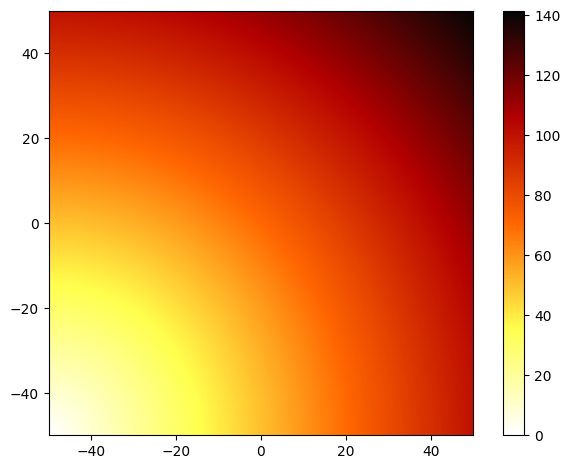

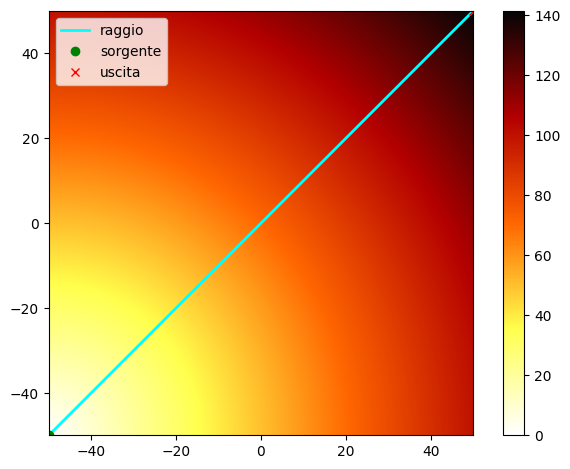

In [ ]:
# ==============================================================================
# VERSIONE FIM JACOBI SENZA LISTA PARALLELIZZATA IN RAWKERNEL
# ==============================================================================

#------------------  LIBRERIE --------------------------------------------------

import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
import numpy.ma as ma
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive
from scipy.ndimage import distance_transform_edt

#------------------  DISCRETIZZAZIONE DEL DOMINIO ------------------------------

# dominio 2000x2000

nx = 5000
ny = 5000
nRows = 5000
nCols = 5000
sidex = 50
sidey = 50
domain = [-sidex, sidex, -sidey, sidey]
x = np.linspace(domain[0], domain[1], nx)
y = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[X, Y] = np.meshgrid(x, y)
eps = 1e-6

ix0 = 5
iy0 = 5


#------------------  CAMPO DI VELOCITA' (LABIRINTO) ----------------------------
h = dx

F = np.ones(X.shape, dtype=np.float32)

wall_mask = np.isinf(F)

#------------------  FASCIA DI SICUREZZA AI MURI -------------------------------

def inflate_walls_smooth(F, wall_mask, margin_cells, penalty_factor):
    F_smooth = F.copy()
    dist_to_wall = distance_transform_edt(~wall_mask)   # distanza in celle dal muro più vicino
    ramp = np.clip(dist_to_wall / margin_cells, 0.0, 1.0)
    F_ramped = penalty_factor + (1.0 - penalty_factor) * ramp
    F_smooth[~wall_mask] = F_ramped[~wall_mask]
    return F_smooth

F_safe = inflate_walls_smooth(F, wall_mask, margin_cells=6, penalty_factor=0.3)

# ==============================================================================
# CALCOLO ICONALE PARALLELIZZATO IN RAWKERNEL
# ==============================================================================

#------------------  SORGENTE --------------------------------------------------

T = np.full(X.shape, 1e30, dtype=np.float32)
T[iy0, ix0] = 0.0

#------------------  UPLOAD CPU -> GPU -----------------------------------------

T_gpu = cp.array(T)
F_gpu = cp.array(F_safe)

#------------------ GODUNOV 1 --------------------------------------------------

godunov_code = godunov_code = r'''
extern "C" __global__
void godunov_update_full(
    const float* T,
    const float* F,
    float*       T_new,
    int          nRows,
    int          nCols,
    float        h
) {

    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= nRows * nCols) return;

    int r = idx / nCols;
    int c = idx % nCols;

    // nodo muro
    float f = F[idx];
    if (isinf(f)) {
        T_new[idx] = 1e30f;
        return;
    }

    // nodo sorgente: non toccare mai
    if (T[idx] == 0.0f) {
        T_new[idx] = 0.0f;
        return;
    }

    float left, right, down, up;

    if (c - 1 < 0 || isinf(F[r * nCols + (c-1)]))
        left = 1e30f;
    else
        left = T[r * nCols + (c-1)];

    if (c + 1 >= nCols || isinf(F[r * nCols + (c+1)]))
        right = 1e30f;
    else
        right = T[r * nCols + (c+1)];

    if (r - 1 < 0 || isinf(F[(r-1) * nCols + c]))
        down = 1e30f;
    else
        down = T[(r-1) * nCols + c];

    if (r + 1 >= nRows || isinf(F[(r+1) * nCols + c]))
        up = 1e30f;
    else
        up = T[(r+1) * nCols + c];

    float Txmin = fminf(left, right);
    float Tymin = fminf(down, up);

    float a = fminf(Txmin, Tymin);
    float b = fmaxf(Txmin, Tymin);

    float rhs = h / f;

    float result;
    if ((b - a) < rhs) {
        float disc = 2.0f * rhs*rhs - (a - b)*(a - b);
        if (disc < 0.0f) disc = 0.0f;
        result = (a + b + sqrtf(disc)) / 2.0f;
    } else {
        result = a + rhs;
    }

    T_new[idx] = result;
}
'''

godunov_ker = cp.RawKernel(godunov_code, 'godunov_update_full')


#------------------  AGGIORNAMENTO FIM JACOBI ----------------------------------

"""
def FIM_senzaLista_raw(T, F):
    threads_per_block = 256
    n = nRows * nCols
    blocchi = (n + threads_per_block - 1) // threads_per_block

    T_new  = cp.empty(n, dtype=cp.float32)
    T_flat = T.ravel().copy()
    F_flat = F.ravel()

    while True:
        p_flat = T_flat.copy()

        godunov_ker(
            (blocchi,), (threads_per_block,),
            (T_flat, F_flat, T_new,
             cp.int32(nRows), cp.int32(nCols), cp.float32(h))
        )

        T_flat = cp.minimum(p_flat, T_new)

        maxdiff = cp.max(cp.abs(p_flat - T_flat))
        if maxdiff < eps:
            break

    return T_flat.reshape(nRows, nCols)
"""
#  versione ottimizzata: controlla ogni 25 passi anzichè ad ogni passo, per
#  allegerire il carico computazionale

def FIM_senzaLista_raw(T, F, check_every=25):
    threads_per_block = 256
    n = nRows * nCols
    blocchi = (n + threads_per_block - 1) // threads_per_block

    # due buffer fissi: eliminano la copy() e l'allocazione ripetuta ad ogni iterazione
    T_a = T.ravel().copy()
    T_b = cp.empty(n, dtype=cp.float32)
    T_new = cp.empty(n, dtype=cp.float32)
    F_flat = F.ravel()

    cur, nxt = T_a, T_b
    it = 0

    while True:
        godunov_ker(
            (blocchi,), (threads_per_block,),
            (cur, F_flat, T_new,
             cp.int32(nRows), cp.int32(nCols), cp.float32(h))
        )

        cp.minimum(cur, T_new, out=nxt)  # scrive direttamente nel buffer esistente

        # il controllo di convergenza (che forza sync GPU->CPU) viene fatto
        # solo ogni check_every iterazioni, non ad ogni passo
        if it % check_every == 0:
            maxdiff = float(cp.max(cp.abs(cur - nxt)))
            if maxdiff < eps:
                cur = nxt
                break

        cur, nxt = nxt, cur
        it += 1

    return cur.reshape(nRows, nCols)

#------------------  SOLVE AND UPLOAD GPU -> CPU -------------------------------

T_final_gpu = FIM_senzaLista_raw(T_gpu, F_gpu)

# ── torna su CPU per il plot ──────────────────────────────────────────────────
T_final = cp.asnumpy(T_final_gpu)

#------------------  STAMPA DEI RISULTATI --------------------------------------

# maschera i muri (e qualunque cella rimasta a sentinella) prima del plot
T_masked = ma.masked_where(T_final >= 1e29, T_final)

fig, ax = plt.subplots()
im = ax.imshow(T_masked, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')
plt.colorbar(im, ax=ax)

stops = np.array([
    [1.00, 1.00, 1.00],
    [1.00, 1.00, 0.30],
    [1.00, 0.40, 0.00],
    [0.70, 0.00, 0.00],
    [0.02, 0.02, 0.02],
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)
cmap2.set_bad(color='black')   # colore per le celle mascherate (i muri)
im.set_cmap(cmap2)
plt.tight_layout()
plt.show()


# ==============================================================================
# CALCOLO DEI RAGGI
# ==============================================================================

#------------------ DISCRETIZZAZIONE DEL GRADIENTE -----------------------------

def Gradient_FD(T_final, F, dx, dy):
    wall_mask = np.isinf(F)
    nRows, nCols = T_final.shape

    Tx = np.zeros_like(T_final)
    Ty = np.zeros_like(T_final)

    # --- Derivata rispetto a x (colonne) ---
    valid = ~wall_mask

    left_ok  = np.zeros_like(valid)
    right_ok = np.zeros_like(valid)
    left_ok[:, 1:]  = valid[:, :-1]   # vicino a sinistra è valido
    right_ok[:, :-1] = valid[:, 1:]   # vicino a destra è valido

    T_left  = np.full_like(T_final, np.nan)
    T_right = np.full_like(T_final, np.nan)
    T_left[:, 1:]  = T_final[:, :-1]
    T_right[:, :-1] = T_final[:, 1:]

    both_x = left_ok & right_ok
    only_left_x  = left_ok & ~right_ok    # solo sinistra disponibile → backward diff
    only_right_x = right_ok & ~left_ok    # solo destra disponibile → forward diff

    Tx[both_x] = (T_right[both_x] - T_left[both_x]) / (2 * dx)
    Tx[only_right_x] = (T_right[only_right_x] - T_final[only_right_x]) / dx
    Tx[only_left_x]  = (T_final[only_left_x] - T_left[only_left_x]) / dx
    # entrambi i vicini muro (o cella stessa muro) → Tx resta 0

    # --- Derivata rispetto a y (righe) ---
    down_ok = np.zeros_like(valid)
    up_ok   = np.zeros_like(valid)
    down_ok[1:, :] = valid[:-1, :]    # vicino sotto è valido
    up_ok[:-1, :]  = valid[1:, :]     # vicino sopra è valido

    T_down = np.full_like(T_final, np.nan)
    T_up   = np.full_like(T_final, np.nan)
    T_down[1:, :] = T_final[:-1, :]
    T_up[:-1, :]  = T_final[1:, :]

    both_y = down_ok & up_ok
    only_down_y = down_ok & ~up_ok
    only_up_y   = up_ok & ~down_ok

    Ty[both_y] = (T_up[both_y] - T_down[both_y]) / (2 * dy)
    Ty[only_up_y]   = (T_up[only_up_y] - T_final[only_up_y]) / dy
    Ty[only_down_y] = (T_final[only_down_y] - T_down[only_down_y]) / dy

    # --- Rinormalizzazione secondo l'eikonale: |grad T| = 1/F ---
    grad_norm = np.sqrt(Tx**2 + Ty**2)
    scale = np.zeros_like(grad_norm)
    finite_F = np.isfinite(F) & (grad_norm > 1e-12)
    scale[finite_F] = 1.0 / (F[finite_F] * grad_norm[finite_F])

    Tx = np.where(finite_F, Tx * scale, 0.0)
    Ty = np.where(finite_F, Ty * scale, 0.0)

    # azzera esplicitamente le celle muro
    Tx[wall_mask] = 0.0
    Ty[wall_mask] = 0.0

    return Tx, Ty

Tx = np.zeros_like(T_final)
Ty = np.zeros_like(T_final)

Tx, Ty = Gradient_FD(T_final, F, dx, dy)

#------------------  ADATTAMENTO DEI MURI --------------------------------------

def fill_wall_nans(field, wall_mask):
    """Sostituisce i valori nelle celle muro con quelli della cella valida più vicina."""
    # indici della cella valida più vicina per ogni punto della griglia
    idx = distance_transform_edt(wall_mask, return_distances=False, return_indices=True)
    return field[tuple(idx)]

#------------------  INTERPOLAZIONE BILINEARE ----------------------------------

wall_mask = np.isinf(F)

Tx_filled = fill_wall_nans(Tx, wall_mask)
Ty_filled = fill_wall_nans(Ty, wall_mask)

Tx_interp = RegularGridInterpolator((y, x), Tx_filled, method='linear',
                                     bounds_error=False, fill_value=None)
Ty_interp = RegularGridInterpolator((y, x), Ty_filled, method='linear',
                                     bounds_error=False, fill_value=None)


def grad_at(pt, Tx_interp, Ty_interp):
    """pt = (px, py) in coordinate cartesiane."""
    px, py = pt
    point = np.array([[py, px]])  # RegularGridInterpolator vuole shape (n_points, n_dims)
    gx = Tx_interp(point)[0]
    gy = Ty_interp(point)[0]
    if not (np.isfinite(gx) and np.isfinite(gy)):
        return np.array([0.0, 0.0])
    return np.array([gx, gy])

#------------------  INTEGRAZIONE RK4 ------------------------------------------

def trace_ray_rk4(start_pt, Tx_interp, Ty_interp, source_pt, ds, max_steps):
    """
    Integra all'indietro seguendo -grad(T) a partire da start_pt (uscita)
    fino ad avvicinarsi a source_pt (sorgente).
    """
    pt = np.array(start_pt, dtype=float)
    ray = [pt.copy()]

    for step in range(max_steps):

        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
          break

        k1 = -grad_at(pt, Tx_interp, Ty_interp)
        if np.linalg.norm(k1) < 1e-12:
            break
        k2 = -grad_at(pt + 0.5*ds*k1, Tx_interp, Ty_interp)
        k3 = -grad_at(pt + 0.5*ds*k2, Tx_interp, Ty_interp)
        k4 = -grad_at(pt + ds*k3, Tx_interp, Ty_interp)

        dpt = (k1 + 2*k2 + 2*k3 + k4) / 6.0
        pt_new = pt + ds * dpt

        ray.append(pt_new.copy())

        # criterio di arresto: raggio arrivato vicino alla sorgente
        if np.linalg.norm(pt_new - np.array(source_pt)) < ds:
            ray.append(np.array(source_pt, dtype=float))
            break

        # criterio di stagnazione (raggio bloccato, es. contro un muro)
        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
            break

        pt = pt_new

    return np.array(ray)

#------------------  CALCOLO DEL RAGGIO ALL'INDIETRO ---------------------------

# coordinate cartesiane del punto sorgente
source_pt = (x[ix0], y[iy0])

# punto d'uscita in alto a destra del dominio
exit_pt = (x[4995], y[4995])

ds = dx  # passo di integrazione
max_steps = 10000

ray = trace_ray_rk4(exit_pt, Tx_interp, Ty_interp, source_pt, ds, max_steps)


#------------------  STAMPA DEI RISULTATI --------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal', cmap=cmap2)
plt.colorbar(im, ax=ax)

ax.plot(ray[:, 0], ray[:, 1], color='cyan', linewidth=2, label='raggio')
ax.plot(*source_pt, 'go', label='sorgente')
ax.plot(*exit_pt, 'rx', label='uscita')
ax.legend()
plt.tight_layout()
plt.show()


